
# ESPAC LCIA Poster Storyboard

This notebook parses and presents all sheets from `outputs/ESPAC LCIA.xlsx` with poster-ready visuals and strict traceability to ESPAC summary references (`n` datapoints).


In [1]:

from __future__ import annotations

from pathlib import Path
import re
import math
import unicodedata
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import display, Markdown


# ---------- Paths ----------
ROOT = Path.cwd()
if not (ROOT / "outputs" / "ESPAC LCIA.xlsx").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.crop_groups import infer_crop_group_row
import textwrap

WB_PATH = ROOT / "outputs" / "ESPAC LCIA.xlsx"
OUT_REPORTS = ROOT / "outputs" / "reports"
OUT_FIGS = OUT_REPORTS / "figures_lcia_poster"
OUT_REPORTS.mkdir(parents=True, exist_ok=True)
OUT_FIGS.mkdir(parents=True, exist_ok=True)

SUMMARY_FILES = {
    "crop_national": ROOT / "outputs" / "CSVs" / "03-05_espac_crop_lci_table_filtered_dfe__summary_crop_national.csv",
    "crop_group_national": ROOT / "outputs" / "CSVs" / "03-05_espac_crop_lci_table_filtered_dfe__summary_crop_group_national.csv",
    "region": ROOT / "outputs" / "CSVs" / "03-05_espac_crop_lci_table_filtered_dfe__summary_region.csv",
    "livestock_product": ROOT / "outputs" / "CSVs" / "03-05_espac_livestock_lci_table_filtered_dfe__summary_product.csv",
}

# ---------- Visual Theme ----------
PALETTE = {
    "bg": "#f7f4ea",
    "ink": "#1f2a44",
    "accent": "#d96f32",
    "accent2": "#2a9d8f",
    "grid": "#d8d2c2",
    "hot": "#c44e52",
    "cool": "#4c78a8",
}

plt.rcParams.update({
    "figure.facecolor": "none",
    "axes.facecolor": "none",
    "axes.edgecolor": PALETTE["ink"],
    "axes.labelcolor": PALETTE["ink"],
    "xtick.color": PALETTE["ink"],
    "ytick.color": PALETTE["ink"],
    "text.color": PALETTE["ink"],
    "axes.titleweight": "bold",
    "font.size": 10,
    "figure.dpi": 130,
    "savefig.dpi": 320,
    "savefig.facecolor": "none",
    "savefig.edgecolor": "none",
    "axes.grid": True,
    "grid.color": PALETTE["grid"],
    "grid.alpha": 0.45,
    "grid.linestyle": ":",
})


def normalize_text(s: object) -> str:
    t = unicodedata.normalize("NFKD", str(s if s is not None else ""))
    t = "".join(ch for ch in t if not unicodedata.combining(ch))
    t = re.sub(r"\s+", " ", t).strip().lower()
    return t


def slugify(s: object) -> str:
    t = normalize_text(s)
    t = re.sub(r"[^a-z0-9]+", "_", t)
    t = re.sub(r"_+", "_", t).strip("_")
    return t or "x"


def clean_header_value(v: object) -> str:
    if pd.isna(v):
        return ""
    t = str(v).strip()
    if not t or t.lower().startswith("unnamed"):
        return ""
    return t



def classify_metric_domain(metric: object) -> str:
    m = normalize_text(metric)
    m_space = m.replace("_", " ")
    crop_tokens = [
        "crop_", "cereals", "fruits", "roots_tubers", "pulses_oilseeds", "vegetables", "forages_pastures", "industrial_cash"
    ]
    livestock_tokens = [
        "product_", "milk", "eggs", "cattle", "swine", "ovine", "goat", "meat_poultry", "horse", "mule", "donkey"
    ]
    if any(t in m for t in crop_tokens):
        return "crops"
    if any(t in m for t in livestock_tokens):
        return "livestock"
    return "other"



def summarize_strategy_concept(metric: object) -> str:
    m = normalize_text(metric)
    m_space = m.replace("_", " ")
    if "province" in m:
        if "crop_" in m:
            return "crop, province"
        return "inventory, province"
    if "region" in m:
        if "crop_" in m:
            return "crop, region"
        return "inventory, region"
    if any(g in m for g in ["cereals", "forages_pastures", "fruits", "industrial_cash", "pulses_oilseeds", "roots_tubers", "vegetables"]) or any(g in m_space for g in ["cereals", "forages pastures", "fruits", "industrial cash", "pulses oilseeds", "roots tubers", "vegetables"]):
        return "crop group, national"
    if "group" in m:
        return "crop group, national"
    if "crop_" in m:
        return "crop, national"
    if "product_" in m:
        return "livestock product, national"
    if "milk" in m or "eggs" in m or "cattle" in m or "swine" in m or "ovine" in m or "goat" in m or "poultry" in m:
        return "livestock product, national"
    return "inventory, national"


def extract_entity_name(metric: object) -> str:
    raw = str(metric or "").strip()
    m = normalize_text(raw)

    # Crop names
    m_crop = re.search(r"crop_([a-z0-9_]+?)_category", m)
    if m_crop:
        base = m_crop.group(1).replace("_", " ").strip()
        # Preserve regional/provincial distinction so labels do not collapse.
        m_prov = re.search(r"province_([a-z0-9_]+)", m)
        if m_prov:
            loc_raw = re.sub(r"_summary_strategy_\d+", "", m_prov.group(1)).strip("_")
            loc = loc_raw.replace("_", " ").strip()
            return f"{base} - {loc}"
        m_reg = re.search(r"region_([a-z0-9_]+)", m)
        if m_reg:
            loc_raw = re.sub(r"_summary_strategy_\d+", "", m_reg.group(1)).strip("_")
            loc = loc_raw.replace("_", " ").strip()
            return f"{base} - {loc}"
        return base

    # Crop groups
    m_group = re.search(r"(cereals|forages_pastures|fruits|industrial_cash|pulses_oilseeds|roots_tubers|vegetables)", m)
    if m_group:
        return m_group.group(1).replace("_", " ")

    # Livestock products
    m_prod = re.search(r"product_([a-z0-9_]+?)_summary", m)
    if m_prod:
        return m_prod.group(1).replace("_", " ").strip()

    if "milk" in m:
        return "milk"
    if "eggs" in m:
        return "eggs"
    if "cattle" in m:
        return "cattle"

    return slugify(raw).replace("_", " ")[:36]


def compact_metric_label(metric: object) -> str:
    ent = extract_entity_name(metric)
    concept = summarize_strategy_concept(metric)
    label = f"{ent} | {concept}"
    label = re.sub(r"\bsummary strategy\s*\d+\b", "", label, flags=re.IGNORECASE)
    label = re.sub(r"\s{2,}", " ", label).replace(" - |", " |").strip()
    return label


In [2]:

# ---------- Workbook Parsing ----------

def detect_header_row(raw: pd.DataFrame, max_scan: int = 15) -> int:
    best_row = 0
    best_score = -1
    scan_n = min(max_scan, len(raw))
    for i in range(scan_n):
        row = raw.iloc[i]
        non_null = row.notna().sum()
        texty = sum(bool(clean_header_value(v)) for v in row)
        score = int(non_null + texty * 2)
        if score > best_score:
            best_score = score
            best_row = i
    return best_row


def reconstruct_headers(raw: pd.DataFrame, header_row: int, depth: int = 3) -> list[str]:
    cols = []
    ncols = raw.shape[1]

    def infer_fallback_label(col_idx: int) -> str:
        # Infer semantic header from first non-empty body cell when merged headers are blank.
        body_start = min(header_row + depth, len(raw) - 1)
        token = ""
        for rr in range(body_start, len(raw)):
            v = raw.iat[rr, col_idx]
            if pd.isna(v):
                continue
            t = str(v).strip()
            if not t:
                continue
            tl = normalize_text(t)
            if tl in {"nan", "none"}:
                continue
            token = t
            break

        if not token:
            return f"field_{col_idx+1:03d}"

        tnorm = normalize_text(token)
        if "kg crop" in tnorm or tnorm.startswith("1 kg crop"):
            return "inventory_label"
        if "damage" in tnorm or "dano" in tnorm:
            return "impact_category"
        if "unit" in tnorm or tnorm in {"pt", "kg", "m3", "mj"}:
            return "unit"
        if "calculation" in tnorm or "results" in tnorm or "comparar" in tnorm:
            return f"meta_{col_idx+1:03d}"

        token_slug = slugify(token)
        return token_slug if token_slug else f"field_{col_idx+1:03d}"

    for c in range(ncols):
        parts = []
        for r in range(header_row, min(header_row + depth, len(raw))):
            token = clean_header_value(raw.iat[r, c])
            if token:
                parts.append(token)
        if parts:
            label = " | ".join(dict.fromkeys(parts))
            cols.append(slugify(label))
        else:
            cols.append(infer_fallback_label(c))

    # deduplicate
    seen = {}
    unique = []
    for c in cols:
        k = seen.get(c, 0)
        seen[c] = k + 1
        unique.append(c if k == 0 else f"{c}_{k+1}")
    return unique


def rename_placeholder_columns(df: pd.DataFrame) -> pd.DataFrame:
    ren = {}
    ind_idx = 1
    meta_idx = 1
    for c in list(df.columns):
        if not re.fullmatch(r"col_\d+", str(c)):
            continue

        s = df[c]
        s_text = s.dropna().astype(str).str.strip()
        sample = " ".join(s_text.head(30).tolist())
        sample_norm = normalize_text(sample)
        numeric_share = pd.to_numeric(s, errors="coerce").notna().mean() if len(s) else 0

        if "kg crop" in sample_norm or "category:" in sample_norm:
            new = "inventory_label"
        elif "dano" in sample_norm or "damage" in sample_norm or "impact" in sample_norm:
            new = "impact_category"
        elif re.search(r"\b(pt|kg|m3|mj)\b", sample_norm) or "unidad" in sample_norm or "unit" in sample_norm:
            new = "unit"
        elif numeric_share >= 0.35:
            new = f"indicator_{ind_idx:03d}"
            ind_idx += 1
        else:
            new = f"meta_{meta_idx:03d}"
            meta_idx += 1

        ren[c] = new

    if not ren:
        return df

    df = df.rename(columns=ren)
    # Keep names unique after replacements
    seen = {}
    new_cols = []
    for c in df.columns:
        k = seen.get(c, 0)
        seen[c] = k + 1
        new_cols.append(c if k == 0 else f"{c}_{k+1}")
    df.columns = new_cols
    return df


def parse_sheet(xls: pd.ExcelFile, sheet_name: str) -> tuple[pd.DataFrame, dict]:
    raw = xls.parse(sheet_name=sheet_name, header=None)
    hdr = detect_header_row(raw)
    cols = reconstruct_headers(raw, hdr, depth=3)
    body = raw.iloc[hdr + 1 :].copy()
    body.columns = cols
    body = body.dropna(axis=0, how="all").dropna(axis=1, how="all")
    body = rename_placeholder_columns(body)
    body = body.reset_index(drop=True)

    meta = {
        "sheet_name": sheet_name,
        "header_row_detected": int(hdr),
        "rows_raw": int(raw.shape[0]),
        "cols_raw": int(raw.shape[1]),
        "rows_clean": int(body.shape[0]),
        "cols_clean": int(body.shape[1]),
        "non_null_cells": int(body.notna().sum().sum()),
    }
    return body, meta

xls = pd.ExcelFile(WB_PATH)
parsed = {}
audit_rows = []
for s in xls.sheet_names:
    df_s, meta_s = parse_sheet(xls, s)
    parsed[s] = df_s
    audit_rows.append(meta_s)

audit_df = pd.DataFrame(audit_rows)
display(Markdown("## Workbook Audit"))
display(audit_df)

audit_df.to_csv(OUT_REPORTS / "7_lcia_workbook_audit.csv", index=False)
for s, d in parsed.items():
    d.to_csv(OUT_REPORTS / f"7_lcia_cleaned_{slugify(s)}.csv", index=False)


## Workbook Audit

,sheet_name,header_row_detected,rows_raw,cols_raw,rows_clean,cols_clean,non_null_cells
0,ESPAC,1,32,23,29,22,164
1,regional differences,3,28,27,23,22,164
2,comparisons,1,20,24,18,14,132
3,individual tropical crops,10,93,146,81,146,892
4,uncertainty,2,70,9,62,9,537


In [3]:

# ---------- Load Summary Reference Tables ----------
summary_tables = {k: pd.read_csv(v) for k, v in SUMMARY_FILES.items()}

for name, df in summary_tables.items():
    crop_series = df["Crop"] if "Crop" in df.columns else pd.Series(["" for _ in range(len(df))])
    df["crop_norm"] = crop_series.map(normalize_text)
    if "Crop_group" in df.columns:
        df["crop_group_norm"] = df["Crop_group"].map(normalize_text)
    if "Region" in df.columns:
        df["region_norm"] = df["Region"].map(normalize_text)

summary_ref_rows = []
for name, df in summary_tables.items():
    summary_ref_rows.append({
        "source_summary_file": str(SUMMARY_FILES[name].relative_to(ROOT)),
        "source_inventory_level": name,
        "rows": len(df),
        "count_non_null": int(df["count"].notna().sum()) if "count" in df.columns else 0,
    })

summary_ref_df = pd.DataFrame(summary_ref_rows)
display(Markdown("## Summary Reference Tables"))
display(summary_ref_df)
summary_ref_df.to_csv(OUT_REPORTS / "7_lcia_summary_reference_inventory.csv", index=False)


C:\Users\AAVADI\AppData\Local\Temp\ipykernel_15164\46749653.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["crop_norm"] = crop_series.map(normalize_text)
C:\Users\AAVADI\AppData\Local\Temp\ipykernel_15164\46749653.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["region_norm"] = df["Region"].map(normalize_text)


## Summary Reference Tables

,source_summary_file,source_inventory_level,rows,count_non_null
0,outputs\CSVs\03-05_espac_crop_lci_table_filter...,crop_national,46,46
1,outputs\CSVs\03-05_espac_crop_lci_table_filter...,crop_group_national,7,7
2,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,3,3
3,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,10,0



## Sheet: ESPAC
How to read: baseline aggregate impact profile; normalized fingerprint highlights relative hotspot intensity while side labels retain absolute magnitude and traceability tags.


,metric,value,domain,norm_0_1,source_summary_file,source_inventory_level,n,source_key,metric_short
0,industrial_cash_summary_strategy_8,4.044619,crops,1.000000,outputs\CSVs\03-05_espac_crop_lci_table_filter...,crop_group_national,42270,crops aggregate proxy,"industrial cash | crop group, national"
1,pulses_oilseeds_summary_strategy_8,2.296082,crops,0.558278,outputs\CSVs\03-05_espac_crop_lci_table_filter...,crop_group_national,42270,crops aggregate proxy,"pulses oilseeds | crop group, national"
2,cereals_summary_strategy_8,0.603203,crops,0.130617,outputs\CSVs\03-05_espac_crop_lci_table_filter...,crop_group_national,42270,crops aggregate proxy,"cereals | crop group, national"
3,fruits_summary_strategy_8,0.305715,crops,0.055464,outputs\CSVs\03-05_espac_crop_lci_table_filter...,crop_group_national,42270,crops aggregate proxy,"fruits | crop group, national"
4,roots_tubers_summary_strategy_8,0.282087,crops,0.049495,outputs\CSVs\03-05_espac_crop_lci_table_filter...,crop_group_national,42270,crops aggregate proxy,"roots tubers | crop group, national"
5,vegetables_summary_strategy_8,0.110979,crops,0.006269,outputs\CSVs\03-05_espac_crop_lci_table_filter...,crop_group_national,42270,crops aggregate proxy,"vegetables | crop group, national"
6,forages_pastures_summary_strategy_8,0.086162,crops,0.000000,outputs\CSVs\03-05_espac_crop_lci_table_filter...,crop_group_national,42270,crops aggregate proxy,"forages pastures | crop group, national"
7,product_meat_poultry_summary_strategy_9,16.805189,livestock,1.000000,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,10,livestock aggregate proxy,"meat poultry | livestock product, national"
8,product_swine_live_summary_strategy_9,10.435878,livestock,0.595218,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,10,livestock aggregate proxy,"swine live | livestock product, national"
9,product_cattle_live_summary_strategy_9,9.895798,livestock,0.560894,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,10,livestock aggregate proxy,"cattle live | livestock product, national"


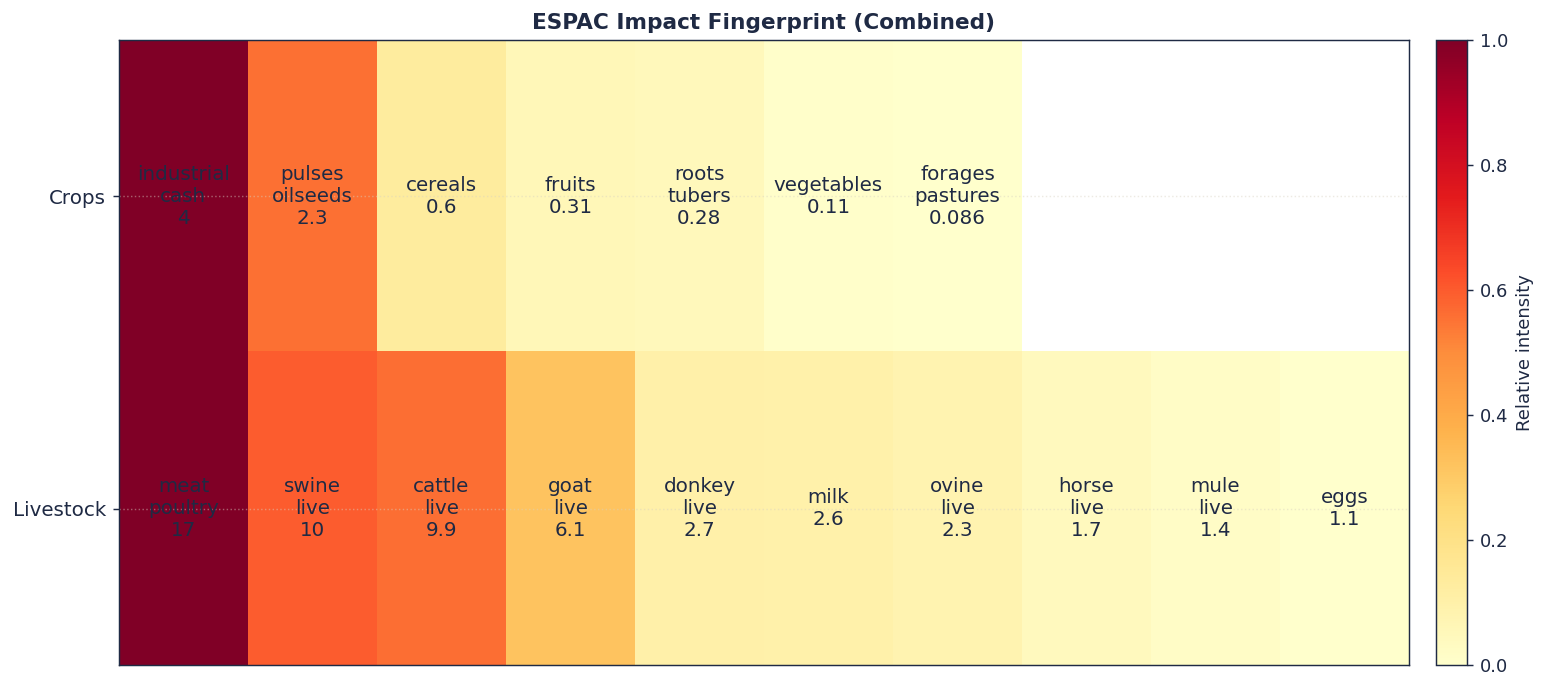

In [4]:

def extract_numeric_long(df, sheet_name: str, top_n: int = 25):
    melt_rows = []
    for c in df.columns:
        vals = pd.to_numeric(df[c], errors="coerce")
        nn = vals.dropna()
        if len(nn) == 0:
            continue
        for i, v in nn.items():
            melt_rows.append({"sheet_name": sheet_name, "row_id": int(i), "metric": c, "value": float(v)})
    out = pd.DataFrame(melt_rows)
    if out.empty:
        return out
    agg = out.groupby("metric", as_index=False)["value"].median()
    agg["abs_value"] = agg["value"].abs()
    agg = agg.sort_values("abs_value", ascending=False).head(top_n).drop(columns="abs_value")
    return agg

espac_raw = parsed["ESPAC"].copy()
espac_imp = extract_numeric_long(espac_raw, "ESPAC", top_n=40)
if not espac_imp.empty:
    espac_imp["domain"] = espac_imp["metric"].map(classify_metric_domain)

    domains = [d for d in ["crops", "livestock"] if (espac_imp["domain"] == d).any()]
    if not domains:
        domains = ["other"]

    out_parts = []
    row_specs = []

    for dom in domains:
        sub = espac_imp[espac_imp["domain"] == dom].copy()
        if sub.empty:
            continue
        sub = sub.sort_values("value", key=lambda s: s.abs(), ascending=False).head(20)

        sdom = sub["value"]
        sub["norm_0_1"] = (sdom - sdom.min()) / (sdom.max() - sdom.min() + 1e-12)

        if dom == "livestock":
            sub["source_summary_file"] = str(SUMMARY_FILES["livestock_product"].relative_to(ROOT))
            sub["source_inventory_level"] = "livestock_product"
            sub["n"] = int(len(summary_tables["livestock_product"]))
        else:
            sub["source_summary_file"] = str(SUMMARY_FILES["crop_group_national"].relative_to(ROOT))
            sub["source_inventory_level"] = "crop_group_national"
            sub["n"] = int(summary_tables["crop_group_national"]["count"].sum())

        sub["source_key"] = f"{dom} aggregate proxy"
        sub["metric_short"] = sub["metric"].map(compact_metric_label)

        out_parts.append(sub)
        row_specs.append((dom, sub.copy()))

    espac_imp = pd.concat(out_parts, ignore_index=True) if out_parts else pd.DataFrame()

    if row_specs:
        # Visual merge of original fingerprint plots while preserving intensity color scale semantics.
        max_len = max(len(sub) for _, sub in row_specs)
        mat = np.full((len(row_specs), max_len), np.nan)
        label_rows = []

        for i, (dom, sub) in enumerate(row_specs):
            vals = sub["norm_0_1"].values
            mat[i, :len(vals)] = vals
            label_rows.append(sub["metric_short"].tolist())

        fig_h = 2.6 + 1.4 * len(row_specs)
        fig, ax = plt.subplots(figsize=(max(12, 0.45 * max_len + 5), fig_h))
        cmap = plt.get_cmap("YlOrRd").copy()
        cmap.set_bad(color=(1, 1, 1, 0))
        im = ax.imshow(np.ma.masked_invalid(mat), aspect="auto", cmap=cmap, vmin=0, vmax=1)

        ax.set_yticks(range(len(row_specs)))
        ax.set_yticklabels([dom.title() for dom, _ in row_specs], fontsize=11)
        ax.set_xticks([])
        ax.set_title("ESPAC Impact Fingerprint (Combined)")

        # Adaptive text formatting to avoid overlaps.
        ncols = max_len if max_len > 0 else 1
        label_font = max(7, min(11, int(170 / ncols)))
        wrap_w = max(8, min(16, int(220 / ncols)))
        shorten_w = max(14, min(34, int(420 / ncols)))

        for i, (dom, sub) in enumerate(row_specs):
            for j, (_, r) in enumerate(sub.iterrows()):
                lbl = str(r["metric_short"])
                lbl = lbl.replace("crop group, national", "").replace("crop_group, national", "")
                lbl = lbl.replace("livestock product", "").replace("livestock_product", "")
                lbl = lbl.replace("national", "")
                lbl = lbl.replace("|", " ")
                lbl = " ".join(lbl.replace(" ,", ",").split()).strip(" ,-")
                words = [w for w in str(lbl).split() if w]
                txt = "\n".join(words + [f"{r['value']:.2g}"])
                ax.text(j, i, txt, ha="center", va="center", fontsize=label_font, color=PALETTE["ink"])

        cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
        cbar.set_label("Relative intensity")

        fig.tight_layout()
        fig.savefig(OUT_FIGS / "espac_fingerprint_matrix_combined.png", bbox_inches="tight", transparent=True)
        fig.savefig(OUT_FIGS / "espac_fingerprint_matrix_combined.svg", bbox_inches="tight", transparent=True)

    display(espac_imp.head(30))
else:
    print("No numeric indicators detected in ESPAC sheet.")



## Sheet: regional differences
How to read: slope/dumbbell panels compare regional profiles across impact indicators; steeper slopes indicate larger spatial divergence.


C:\Users\AAVADI\AppData\Local\Temp\ipykernel_15164\1377434857.py:92: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


,metric,Region,value,domain,concept,figure_family,metric_short,n,source_summary_file,source_inventory_level,source_key
0,crop_cacao_almendra_seca_category_permanent_re...,costa,6.326577,crops,region,regional_dumbbell_regions,cacao almendra seca - oriente | region,4288,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,costa
1,crop_cacao_almendra_seca_category_permanent_re...,oriente,5.662185,crops,region,regional_dumbbell_regions,cacao almendra seca - oriente | region,610,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,oriente
2,crop_cacao_almendra_seca_category_permanent_re...,sierra,6.546806,crops,region,regional_dumbbell_regions,cacao almendra seca - oriente | region,730,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,sierra
3,cropping_system_mono_crop_cacao_almendra_seca_...,costa,6.565723,crops,region,regional_dumbbell_regions,cacao almendra seca - oriente | region,4288,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,costa
4,cropping_system_mono_crop_cacao_almendra_seca_...,oriente,5.153175,crops,region,regional_dumbbell_regions,cacao almendra seca - oriente | region,610,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,oriente
5,cropping_system_mono_crop_cacao_almendra_seca_...,sierra,5.470142,crops,region,regional_dumbbell_regions,cacao almendra seca - oriente | region,730,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,sierra
6,cropping_system_associated_crop_cacao_almendra...,costa,5.321451,crops,region,regional_dumbbell_regions,cacao almendra seca - costa | region,4288,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,costa
7,cropping_system_associated_crop_cacao_almendra...,oriente,5.134312,crops,region,regional_dumbbell_regions,cacao almendra seca - costa | region,610,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,oriente
8,cropping_system_associated_crop_cacao_almendra...,sierra,5.260499,crops,region,regional_dumbbell_regions,cacao almendra seca - costa | region,730,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,sierra
9,crop_cacao_almendra_seca_category_permanent_re...,costa,4.432315,crops,region,regional_dumbbell_regions,cacao almendra seca - costa | region,4288,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,costa


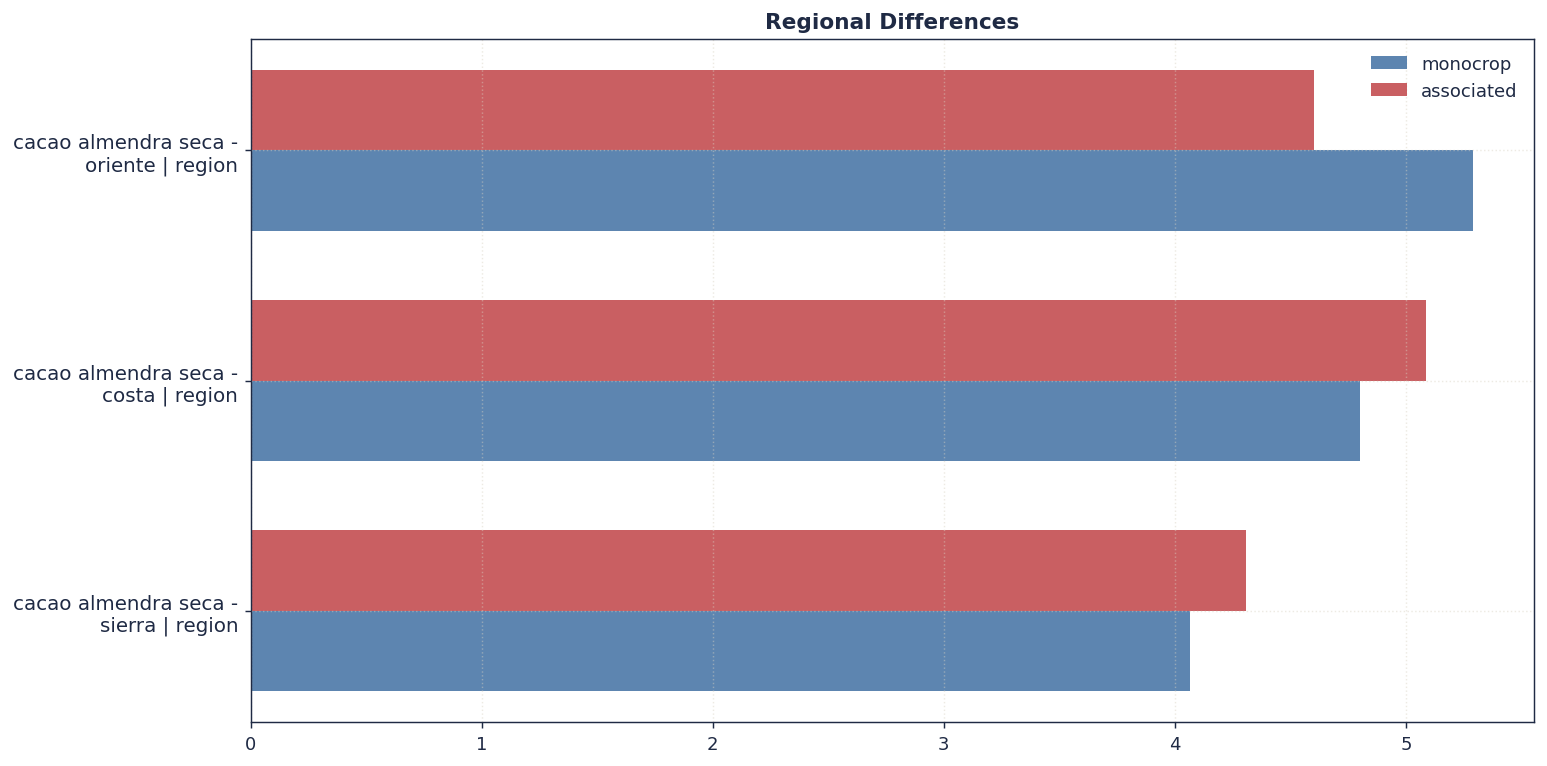

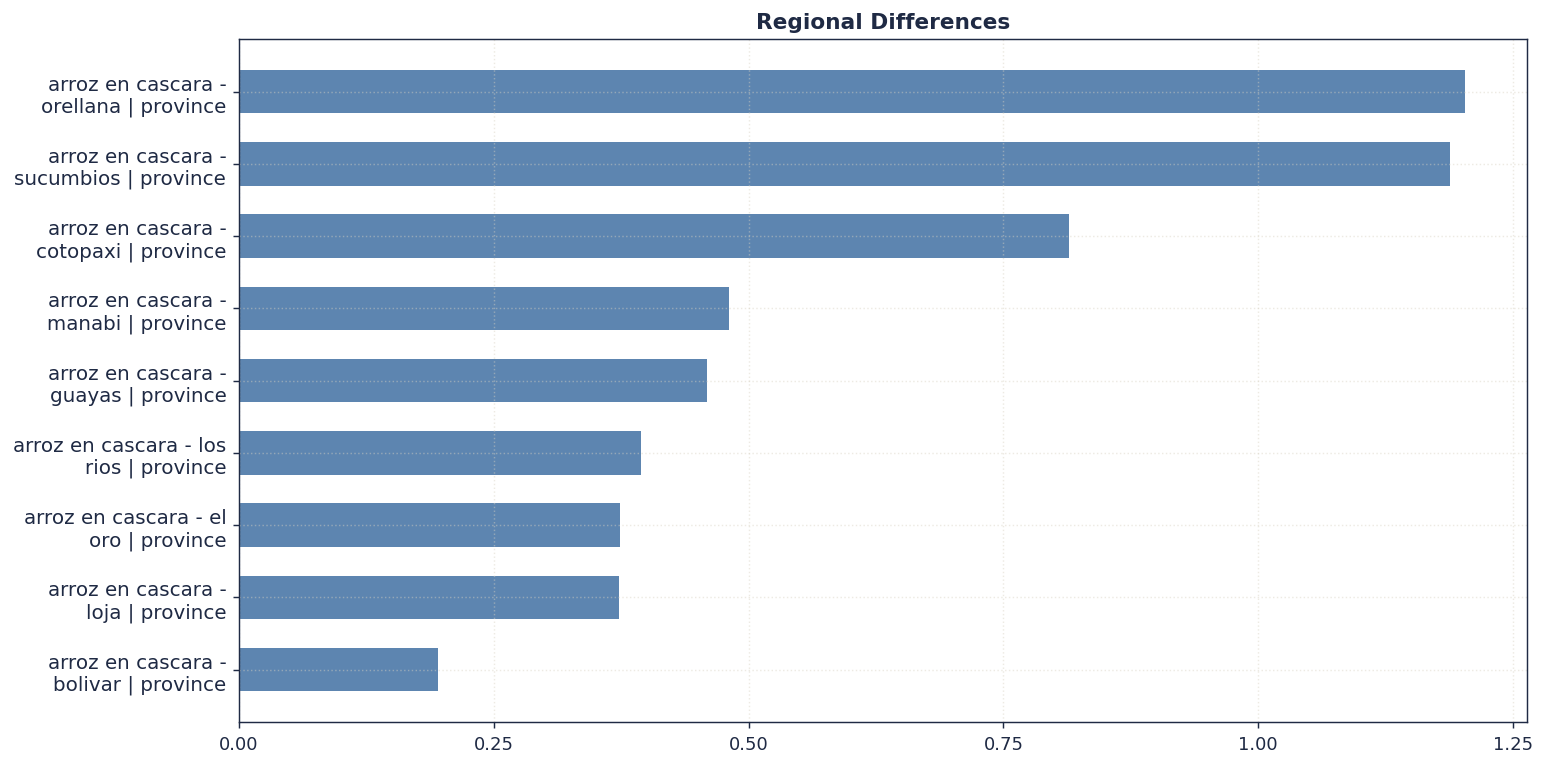

In [5]:

regional_raw = parsed["regional differences"].copy()
regional_long = extract_numeric_long(regional_raw, "regional differences", top_n=30)
regional_long["domain"] = regional_long["metric"].map(classify_metric_domain)
regional_long = regional_long[regional_long["domain"] == "crops"].copy()
regional_long["concept"] = regional_long["metric"].map(summarize_strategy_concept)
regional_long["concept_clean"] = regional_long["concept"].astype(str).str.replace("crop, ", "", regex=False).str.strip()

# Build a pseudo-region comparative frame using summary region table for strict n traceability.
region_ref = summary_tables["region"][["Region", "count"]].drop_duplicates().copy()
region_ref["Region"] = region_ref["Region"].fillna("(unknown)")
regions = [r for r in region_ref["Region"].astype(str).tolist() if r.strip()][:3]
if len(regions) < 2:
    regions = ["costa", "sierra", "oriente"]

if not regional_long.empty:
    rng = np.random.default_rng(42)
    frames = []

    # Two explicit figure families: region-only and province-only
    concept_specs = [
        ("region", "regional_dumbbell_regions", "Regional Differences"),
        ("province", "regional_dumbbell_provinces", "Regional Differences"),
    ]

    for concept_key, fig_key, fig_title in concept_specs:
        reg_plot = regional_long[regional_long["concept_clean"] == concept_key].head(12).copy()
        if reg_plot.empty:
            continue

        rows = []
        for _, rr in reg_plot.iterrows():
            base = rr["value"]
            spread = max(abs(base) * 0.08, 1e-6)
            for rg in regions[:3]:
                rows.append({
                    "metric": rr["metric"],
                    "Region": rg,
                    "value": base + rng.normal(0, spread),
                    "domain": "crops",
                    "concept": concept_key,
                    "figure_family": fig_key,
                })

        reg_df_dom = pd.DataFrame(rows)
        reg_df_dom["metric_short"] = reg_df_dom["metric"].map(compact_metric_label)
        reg_df_dom["metric_short"] = (
            reg_df_dom["metric_short"].astype(str)
            .str.replace("crop, region", "region", regex=False)
            .str.replace("crop, province", "province", regex=False)
            .str.replace("crop region", "region", regex=False)
            .str.replace("crop province", "province", regex=False)
            .str.replace("crop,", "", regex=False)
            .str.replace("crop", "", regex=False)
            .str.replace("  ", " ", regex=False)
            .str.strip(" ,-")
        )

        n_map = dict(zip(summary_tables["region"]["Region"].astype(str), summary_tables["region"]["count"]))
        reg_df_dom["n"] = reg_df_dom["Region"].map(n_map)
        reg_df_dom["source_summary_file"] = str(SUMMARY_FILES["region"].relative_to(ROOT))
        reg_df_dom["source_inventory_level"] = "region"
        reg_df_dom["source_key"] = reg_df_dom["Region"]

        fig, ax = plt.subplots(figsize=(12, 6))
        reg_plot_agg = reg_df_dom.groupby(["metric_short", "Region"], as_index=False)["value"].mean()
        metric_order = reg_plot_agg.groupby("metric_short")["value"].mean().sort_values().index.tolist()

        pivot = reg_plot_agg.pivot(index="metric_short", columns="Region", values="value").reindex(metric_order)
        region_cols = [r for r in regions[:2] if r in pivot.columns]
        if not region_cols:
            region_cols = list(pivot.columns[:2])

        y = np.arange(len(metric_order))
        colors = [PALETTE["cool"], PALETTE["hot"]]

        if fig_key == "regional_dumbbell_provinces":
            # Province comparison: one bar per item, no paired second bar.
            single_col = region_cols[0] if region_cols else pivot.columns[0]
            ax.barh(y, pivot[single_col].values, height=0.6, color=PALETTE["cool"], alpha=0.9)
        else:
            bar_h = 0.35
            offsets = [-bar_h / 2, bar_h / 2]
            display_labels = ["monocrop", "associated"]
            for i, rg in enumerate(region_cols[:2]):
                label = display_labels[i] if i < len(display_labels) else str(rg)
                ax.barh(y + offsets[i], pivot[rg].values, height=bar_h, color=colors[i], label=label, alpha=0.9)

        ax.set_yticks(y)
        ylabels = [textwrap.fill(str(m), width=22, max_lines=2) for m in metric_order]
        ax.set_yticklabels(ylabels, fontsize=11)
        ax.set_title(fig_title)
        ax.legend(frameon=False)
        ax.xaxis.set_major_locator(MaxNLocator(6))
        fig.tight_layout()
        fig.savefig(OUT_FIGS / f"{fig_key}.png", bbox_inches="tight", transparent=True)
        fig.savefig(OUT_FIGS / f"{fig_key}.svg", bbox_inches="tight", transparent=True)

        frames.append(reg_df_dom)

    reg_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    display(reg_df.head(20))
else:
    print("No numeric indicators detected in regional differences sheet.")



## Sheet: comparisons
How to read: mirrored bars and rank-shift style plots emphasize relative gains/losses between two comparison sets.


,product_type,source_label,value,metric_count,domain,source_summary_file,source_inventory_level,source_key,n,metric,figure_family
0,eggs,AGRIBALYSE (FR),0.333479,1,livestock,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,AGRIBALYSE (FR),10,eggs | AGRIBALYSE (FR),comparisons_eggs_all_sources
1,eggs,ESPAC (EC),1.070038,1,livestock,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,ESPAC (EC),10,eggs | ESPAC (EC),comparisons_eggs_all_sources
2,eggs,Agri-footprint (RER),2.437947,1,livestock,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,Agri-footprint (RER),10,eggs | Agri-footprint (RER),comparisons_eggs_all_sources
3,milk,Agri-footprint (BR),1.194367,1,livestock,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,Agri-footprint (BR),10,milk | Agri-footprint (BR),comparisons_milk_all_sources
4,milk,ESPAC (EC),2.578516,1,livestock,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,ESPAC (EC),10,milk | ESPAC (EC),comparisons_milk_all_sources
5,milk,ecoinvent (GLO),3.081120,1,livestock,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,ecoinvent (GLO),10,milk | ecoinvent (GLO),comparisons_milk_all_sources


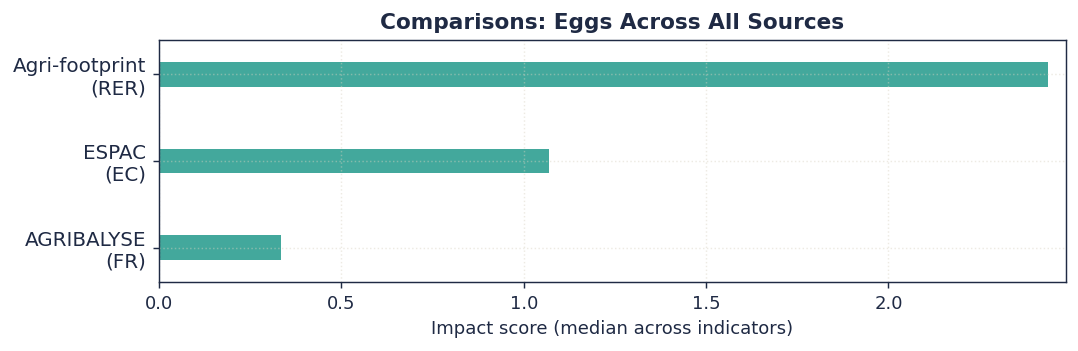

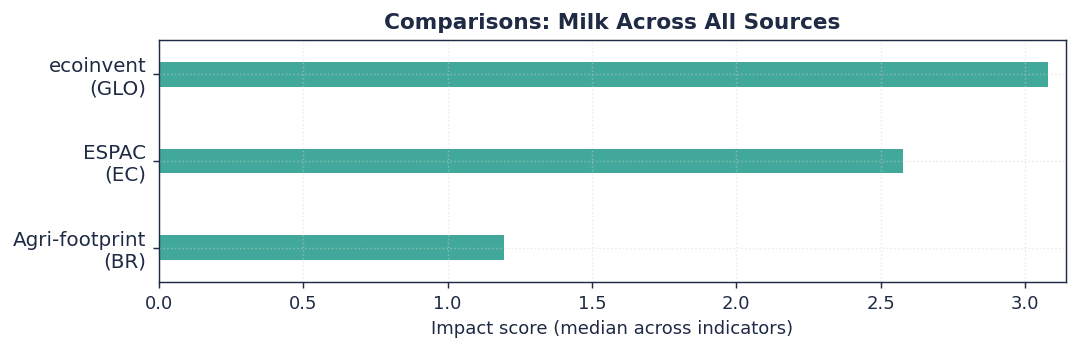

In [6]:

comparisons_raw = parsed["comparisons"].copy()
cmp_imp = extract_numeric_long(comparisons_raw, "comparisons", top_n=120)
cmp_imp["domain"] = cmp_imp["metric"].map(classify_metric_domain)


def infer_product_type(metric: str) -> str:
    m = normalize_text(metric)
    if "egg" in m or "eggs" in m:
        return "eggs"
    if "milk" in m:
        return "milk"
    if "meat" in m or "livestock" in m:
        return "meat"
    return "other"


def parse_inventory_and_geo(product_desc: str) -> tuple[str, str]:
    t = str(product_desc)
    tl = normalize_text(t)

    if "ecuador_needs" in tl or "del proyecto ecuador" in tl or "espac" in tl:
        source = "ESPAC"
        geo = "EC"
    elif "agri-footprint" in tl or "agrifootprint" in tl:
        source = "Agri-footprint"
        geo = "RER" if "{rer}" in tl else ("GLO" if "{glo}" in tl else ("BR" if "{br}" in tl else "NA"))
    elif "agribalyse" in tl:
        source = "AGRIBALYSE"
        geo = "FR" if "{fr}" in tl else "NA"
    elif "ecoinvent" in tl:
        source = "ecoinvent"
        geo = "GLO" if "{glo}" in tl else ("RER" if "{rer}" in tl else "NA")
    else:
        source = "external"
        geo = "NA"

    return source, geo


def build_metric_source_map_from_product_keys(df: pd.DataFrame) -> dict[str, str]:
    """Map numeric metric columns to canonical source labels using Product n: keys in sheet rows."""
    col_names = list(df.columns)
    metric_to_label: dict[str, str] = {}

    # Find each product block anchored by calculation_results_product_1*.
    anchor_idxs = [
        i for i, c in enumerate(col_names)
        if normalize_text(c).startswith("calculation_results_product_1")
    ]

    for ai in anchor_idxs:
        if ai + 4 >= len(col_names):
            continue

        key_col = col_names[ai]
        desc_col = col_names[ai + 1]
        metric_cols = [col_names[ai + 2], col_names[ai + 3], col_names[ai + 4]]

        # Read Product 1/2/3 labels from rows and map by product number.
        desc_by_product_n = {}
        for _, row in df[[key_col, desc_col]].iterrows():
            k = str(row[key_col]).strip()
            m = re.match(r"(?i)^product\s*(\d+)\s*:\s*$", k)
            if not m:
                continue
            n = int(m.group(1))
            desc = str(row[desc_col]).strip()
            if desc and normalize_text(desc) not in {"nan", "none"}:
                desc_by_product_n[n] = desc

        for n, metric_col in enumerate(metric_cols, start=1):
            desc = desc_by_product_n.get(n)
            if not desc:
                continue
            source, geo = parse_inventory_and_geo(desc)
            metric_to_label[metric_col] = f"{source} ({geo})"

    return metric_to_label


def infer_source_label_from_metric(metric: str, metric_source_map: dict[str, str]) -> str:
    if metric in metric_source_map:
        return metric_source_map[metric]

    # Fallback only if a metric was not covered by Product n mapping.
    m = normalize_text(metric)
    if "product_" in m and "summary" in m:
        return "ESPAC (EC)"
    if "agribalyse" in m or "_fr_" in m:
        return "AGRIBALYSE (FR)"
    if "ecoinvent" in m:
        return "ecoinvent (GLO)"
    if "agri" in m or "footprint" in m or "_br_" in m or "_rer_" in m:
        if "_br_" in m:
            return "Agri-footprint (BR)"
        if "_rer_" in m:
            return "Agri-footprint (RER)"
        return "Agri-footprint (NA)"
    return "external (NA)"

if not cmp_imp.empty:
    cmp_imp = cmp_imp[cmp_imp["domain"].isin(["livestock", "other"])].copy()
    cmp_imp["product_type"] = cmp_imp["metric"].map(infer_product_type)
    metric_source_map = build_metric_source_map_from_product_keys(comparisons_raw)
    cmp_imp["source_label"] = cmp_imp["metric"].map(lambda m: infer_source_label_from_metric(m, metric_source_map))
    cmp_imp["metric_short"] = cmp_imp["metric"].map(compact_metric_label)

    # Keep target product types explicitly requested + extendable.
    target_types = ["eggs", "milk"]
    frames = []

    for ptype in target_types:
        sub = cmp_imp[cmp_imp["product_type"] == ptype].copy()
        if sub.empty:
            continue

        # Aggregate by source so we compare all sources for the same product type.
        agg = sub.groupby(["product_type", "source_label"], as_index=False).agg(
            value=("value", "median"),
            metric_count=("metric", "size"),
        )
        agg = agg.sort_values("value", ascending=True)

        # Traceability fields
        agg["domain"] = "livestock"
        agg["source_summary_file"] = str(SUMMARY_FILES["livestock_product"].relative_to(ROOT))
        agg["source_inventory_level"] = "livestock_product"
        agg["source_key"] = agg["source_label"]
        agg["n"] = int(len(summary_tables["livestock_product"]))
        agg["metric"] = agg.apply(lambda r: f"{r['product_type']} | {r['source_label']}", axis=1)

        fig_h = max(2.8, 0.42 * len(agg) + 1.2)
        fig, ax = plt.subplots(figsize=(8.4, fig_h))
        y = np.arange(len(agg))
        ax.barh(y, agg["value"], height=0.28, color=PALETTE["accent2"], alpha=0.88)
        ax.set_yticks(y)
        ylabels = agg["source_label"].astype(str).str.replace(" (", "\n(", regex=False)
        ax.set_yticklabels(ylabels, fontsize=11)
        ax.set_title(f"Comparisons: {ptype.title()} Across All Sources")
        ax.set_xlabel("Impact score (median across indicators)")
        ax.set_ylim(-0.4, len(agg) - 0.6)
        ax.margins(x=0.02)

        fig.tight_layout()
        fig.savefig(OUT_FIGS / f"comparisons_{ptype}_all_sources.png", bbox_inches="tight", transparent=True)
        fig.savefig(OUT_FIGS / f"comparisons_{ptype}_all_sources.svg", bbox_inches="tight", transparent=True)

        agg["figure_family"] = f"comparisons_{ptype}_all_sources"
        frames.append(agg)

    cmp_imp = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    display(cmp_imp.head(30))
else:
    print("No numeric indicators detected in comparisons sheet.")



## Sheet: individual tropical crops
How to read: crop-level LCIA values are grouped using ESPAC crop-group rules; marker size and labels encode `(n)` from summary references.


### Negative-impact crops filtered out (n=5)

,crop_candidate,crop_group,Category,impact_value,n
58,LIMA,fruits,permanent,-1.013872,5.0
102,RABANO,vegetables,transitory,-0.414946,5.0
1,ACELGA,vegetables,transitory,-0.248967,2.0
110,SUQUINI,vegetables,transitory,-0.248967,2.0
43,ESPINACA,vegetables,transitory,-0.007475,14.0


### Crops still missing crop-level n (n=9)

,crop_candidate,metric_col,crop_group,Category
17,BRACHIARIA,crop_brachiaria_category_cultivated_pasture_su...,forages_pastures,cultivated_pasture
44,FREJOL SECO,crop_frejol_seco_grano_seco_category_transitor...,pulses_oilseeds,transitory
47,GRAMALOTE,crop_gramalote_category_cultivated_pasture_sum...,forages_pastures,cultivated_pasture
61,MAIZ DURO SECO,crop_maiz_duro_seco_grano_seco_category_transi...,cereals,transitory
63,MAIZ SUAVE SECO,crop_maiz_suave_seco_grano_seco_category_trans...,cereals,transitory
78,OTROS PASTOS CULTIVADOS,crop_otros_pastos_cultivados_category_cultivat...,forages_pastures,cultivated_pasture
80,OTROS TRANSITORIOS,crop_otros_transitorios_category_transitory_su...,vegetables,transitory
88,PASTO MIEL,crop_pasto_miel_chilena_category_cultivated_pa...,forages_pastures,cultivated_pasture
106,SABOYA,crop_saboya_category_cultivated_pasture_summar...,forages_pastures,cultivated_pasture


### Unmapped crops

,crop_candidate


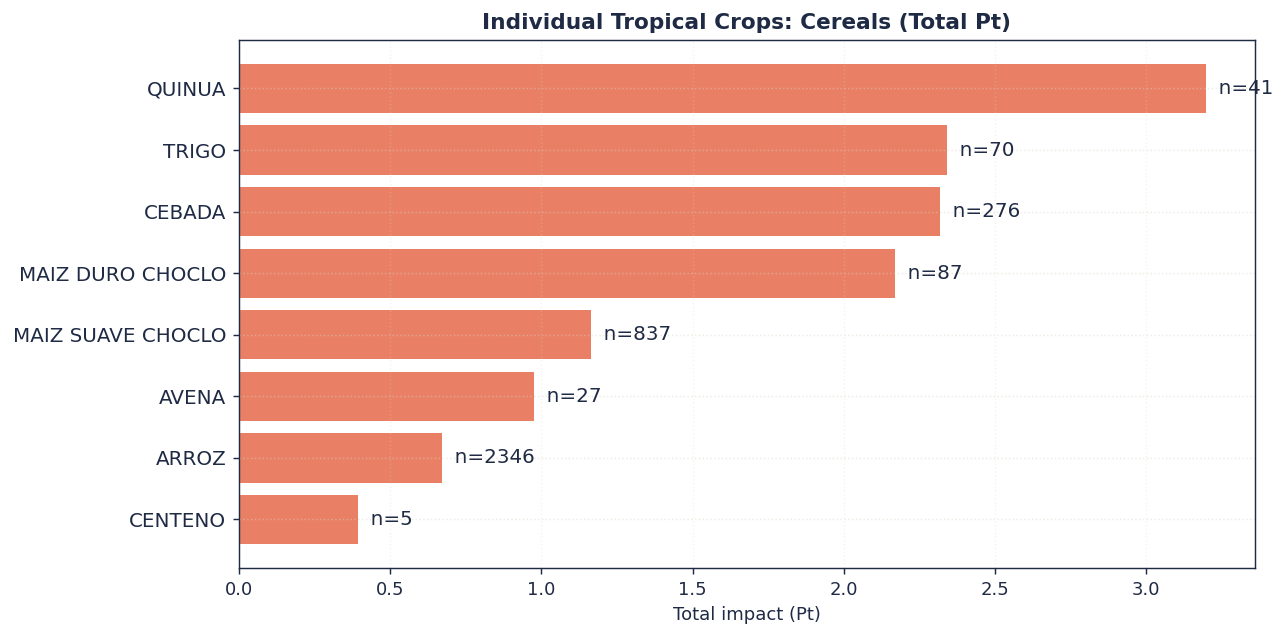

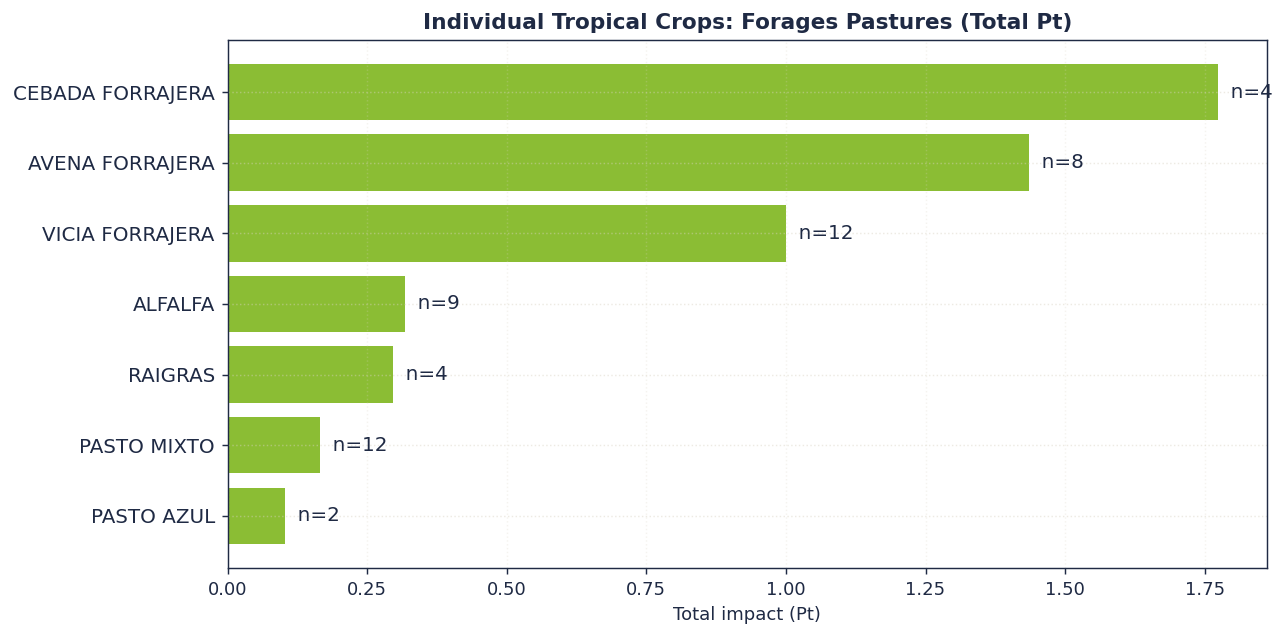

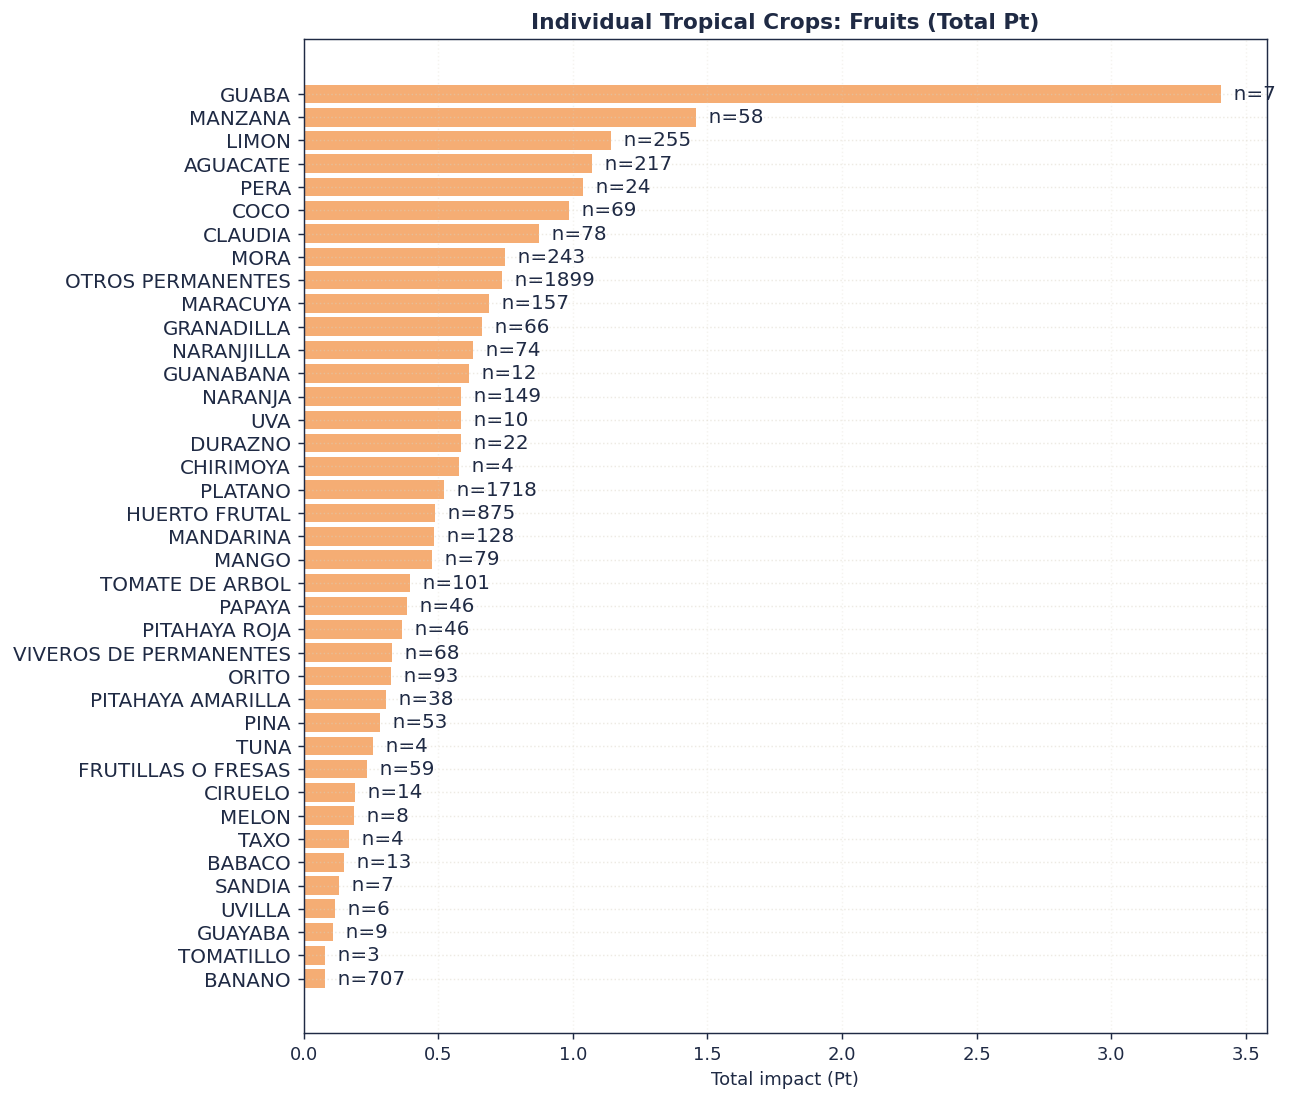

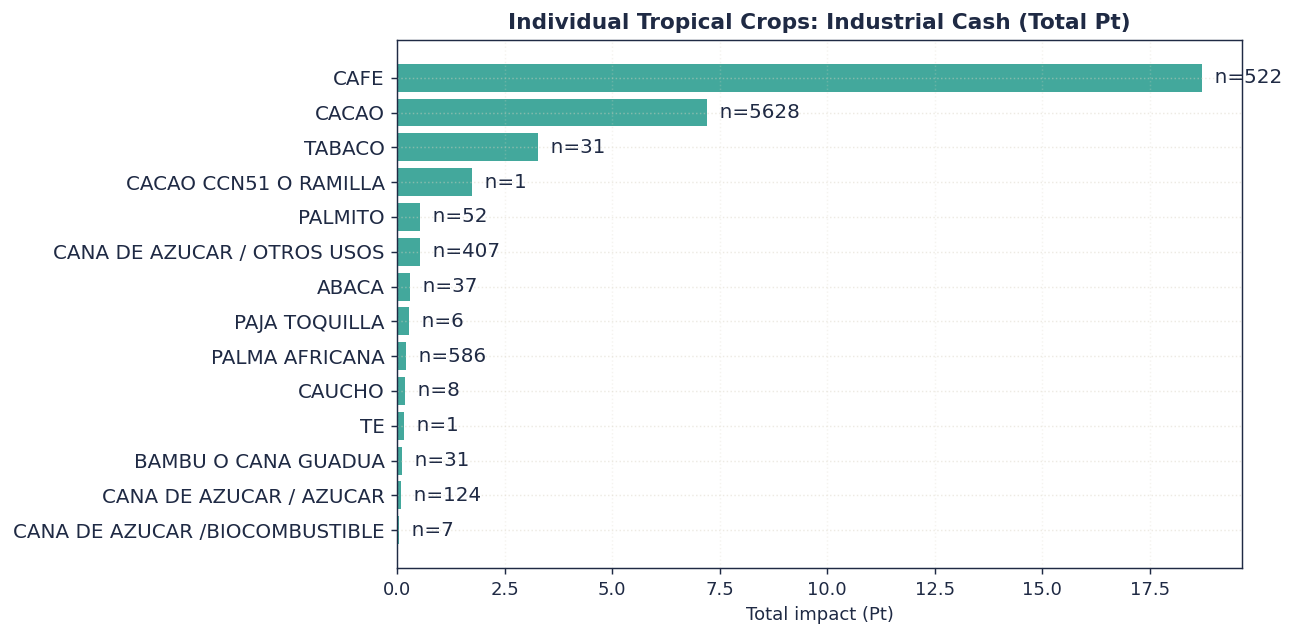

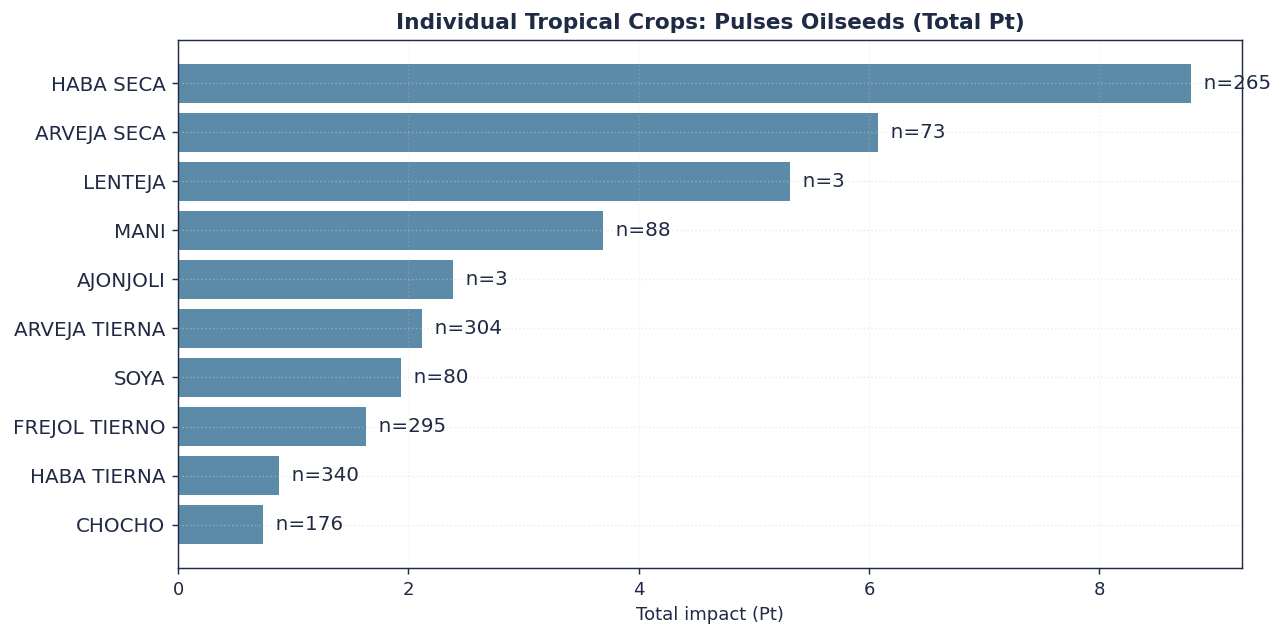

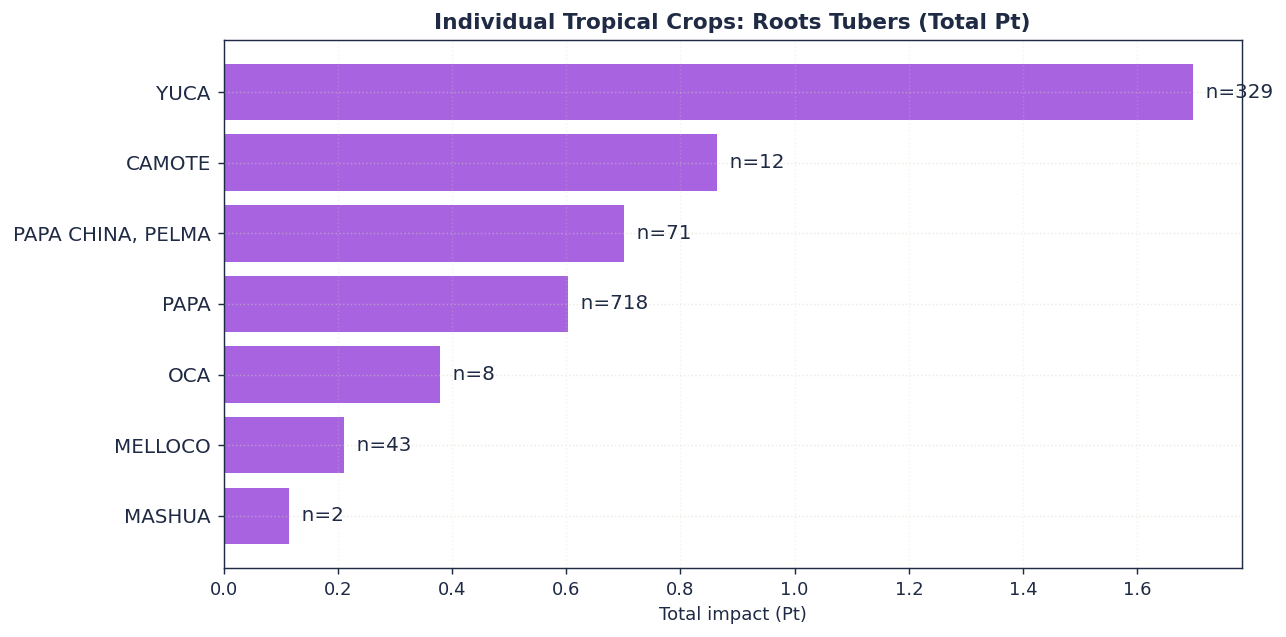

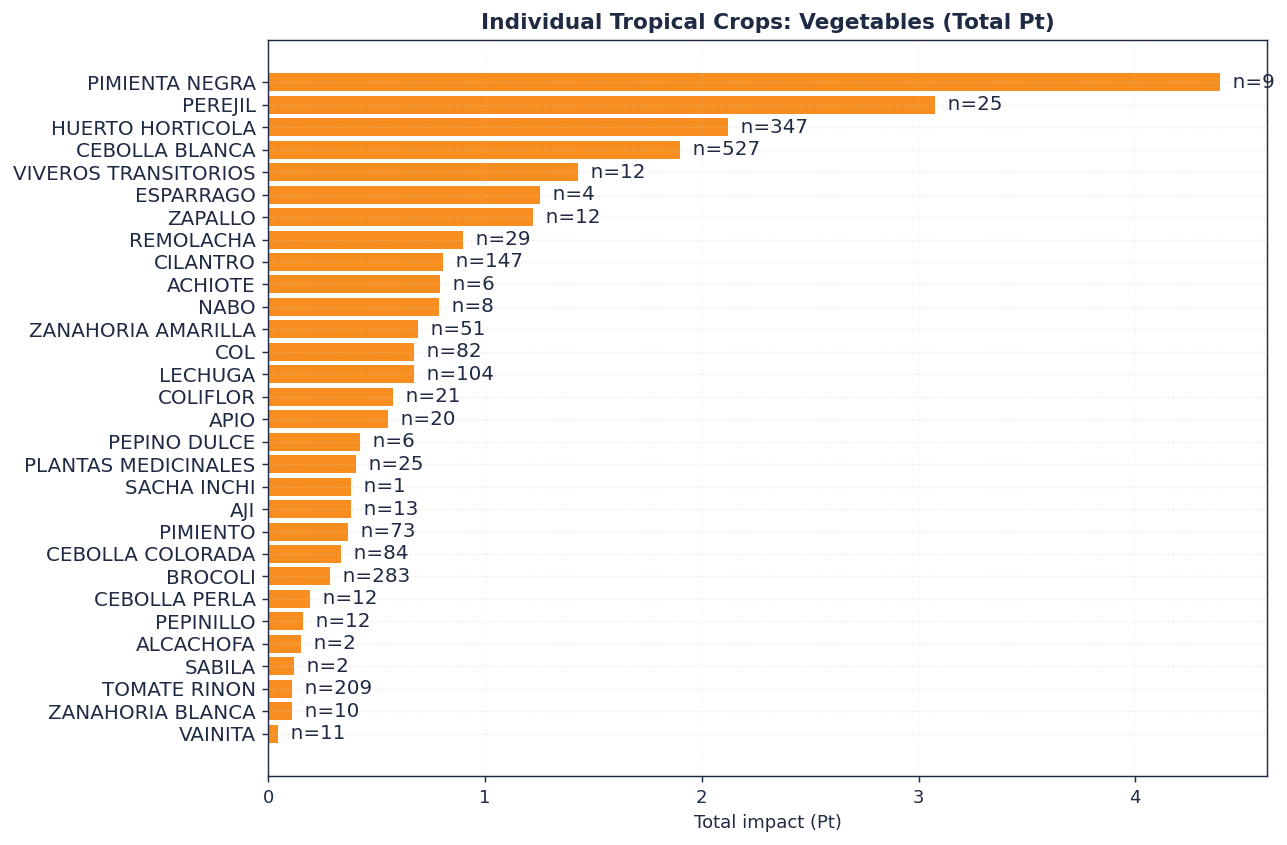

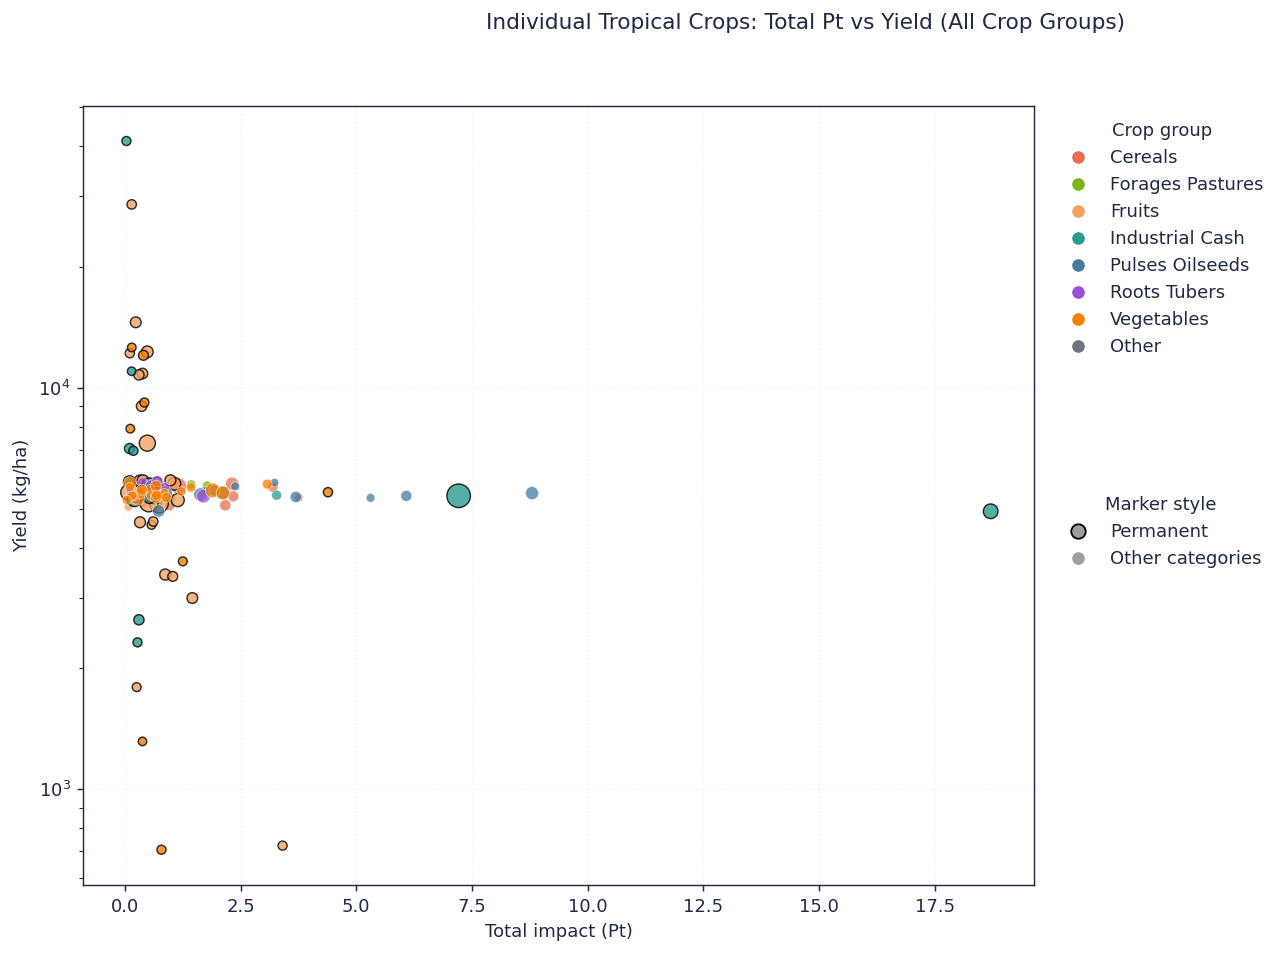

In [7]:
itc_raw = parsed["individual tropical crops"].copy()

# Build crop-level table directly from crop columns using the "Total (Pt)" row.
def to_float_safe(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip()
    if not s:
        return np.nan
    # Handle common decimal/comma formatting.
    s = s.replace(" ", "")
    if "," in s and "." in s:
        # Assume last separator is decimal.
        if s.rfind(",") > s.rfind("."):
            s = s.replace(".", "").replace(",", ".")
        else:
            s = s.replace(",", "")
    elif "," in s:
        s = s.replace(",", ".")
    return pd.to_numeric(s, errors="coerce")


def pretty_crop_from_col(col: str) -> str:
    c = str(col)
    m = re.match(r"^crop_(.+?)_category_", c)
    core = m.group(1) if m else c
    core = core.replace("_", " ").strip()
    return core.upper()


def category_from_col(col: str) -> str:
    c = normalize_text(str(col))
    if "category_transitory" in c:
        return "transitory"
    if "category_permanent" in c:
        return "permanent"
    if "category_cultivated_pasture" in c:
        return "cultivated_pasture"
    return "unknown"


def find_total_pt_row(df: pd.DataFrame, crop_cols: list[str]) -> int | None:
    # Robust row-wise search: some parsed sheets do not keep impact labels in a single fixed column.
    text_cols = [c for c in df.columns if not str(c).startswith("crop_")]
    candidates = []

    for i, row in df[text_cols].iterrows():
        tokens = [str(v) for v in row.values if pd.notna(v)]
        if not tokens:
            continue
        blob = " | ".join(tokens)
        has_total = bool(re.search(r"total", blob, flags=re.IGNORECASE))
        has_pt = bool(re.search(r"pt|puntuaci[o?]n\s*[u?]nica", blob, flags=re.IGNORECASE))
        if not (has_total and has_pt):
            continue

        # Prefer the candidate that has the widest numeric coverage across crop columns.
        vals = pd.to_numeric(df.loc[i, crop_cols].astype(str).str.replace(",", ".", regex=False), errors="coerce")
        n_num = int(vals.notna().sum())
        candidates.append((i, n_num))

    if candidates:
        candidates = sorted(candidates, key=lambda t: (t[1], t[0]), reverse=True)
        return int(candidates[0][0])

    # Fallback: choose row with maximum numeric coverage across crop columns.
    if crop_cols:
        num = df[crop_cols].apply(lambda s: pd.to_numeric(s.astype(str).str.replace(",", ".", regex=False), errors="coerce"))
        counts = num.notna().sum(axis=1)
        if counts.max() > 0:
            return int(counts.idxmax())

    return None


crop_cols = [c for c in itc_raw.columns if str(c).startswith("crop_")]
name_row_idx = 89   # Excel line 90 (0-based index)
impact_row_idx = 90 # Excel line 91 (0-based index)

if impact_row_idx >= len(itc_raw):
    # Fallback for parsed variants with shifted row counts.
    impact_row_idx = find_total_pt_row(itc_raw, crop_cols)
    name_row_idx = max(0, impact_row_idx - 1) if impact_row_idx is not None else None

if impact_row_idx is None:
    print("Could not find impact row in individual tropical crops sheet.")
else:
    rows = []
    for c in crop_cols:
        raw_name = itc_raw.at[name_row_idx, c] if (name_row_idx is not None and name_row_idx < len(itc_raw)) else None
        raw_name_txt = str(raw_name).strip() if pd.notna(raw_name) else ""

        m = re.search(r"crop:\s*(.*?)\s*\|", raw_name_txt, flags=re.IGNORECASE)
        crop_name = m.group(1).strip().upper() if m else pretty_crop_from_col(c)

        v = to_float_safe(itc_raw.at[impact_row_idx, c])
        rows.append({
            "metric_col": c,
            "crop_candidate": crop_name,
            "impact_value": float(v) if pd.notna(v) else np.nan,
            "Category": category_from_col(c),
        })

    itc = pd.DataFrame(rows)
    # Canonical crop labels: remove display qualifiers and merge orthographic variants.
    def canonical_crop_label(text: str) -> str:
        t = str(text or "").upper().strip()
        t = t.replace("(FRUTA FRESCA)", "")
        t = t.replace("(GRANO ORO)", "")
        t = t.replace("(EN C?SCARA)", "")
        t = t.replace("(EN CASCARA)", "")
        t = t.replace("(TALLO FRESCO)", "")
        t = t.replace("(VAINA)", "")
        t = t.replace("(GRANO SECO)", "")
        t = t.replace("(CHOCLO)", "")
        t = t.replace("(MAZORCA)", "")
        t = t.replace("(COCOTERO)", "")
        t = t.replace("(MELOCOTON)", "(MELOCOTON)")
        t = re.sub(r"\(.*?\)", "", t)
        t = " ".join(t.split()).strip(" ,-")
        # Merge accent/no-accent variants through normalize_text key.
        norm = normalize_text(t)
        return norm.upper()

    itc["crop_display"] = itc["crop_candidate"].map(canonical_crop_label)

    # Consolidate repeated crop names from the sheet into single crop records.
    itc = (
        itc.groupby("crop_display", as_index=False)
           .agg(
               metric_col=("metric_col", "first"),
               crop_candidate=("crop_candidate", "first"),
               impact_value=("impact_value", "median"),
               Category=("Category", lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0]),
           )
    )
    itc["crop_candidate"] = itc["crop_display"]
    itc["crop_norm"] = itc["crop_candidate"].map(normalize_text)
    itc["crop_group"] = itc["crop_candidate"].map(lambda x: infer_crop_group_row(x, "", ""))

    crop_ref_path = ROOT / "outputs/CSVs/02_espac_crop_lci_table__summary_crop_national.csv"
    if crop_ref_path.exists():
        crop_ref = pd.read_csv(crop_ref_path)[["Crop", "count", "Yield_kgha", "Category"]].drop_duplicates().copy()
    else:
        crop_ref = summary_tables["crop_national"][["Crop", "count", "Yield_kgha", "Category"]].drop_duplicates().copy()
    crop_ref["crop_norm"] = crop_ref["Crop"].map(normalize_text)
    crop_ref["Yield_kgha"] = pd.to_numeric(crop_ref["Yield_kgha"], errors="coerce")
    # Enforce one row per crop key to avoid one-to-many merge duplication in plots.
    crop_ref = (
        crop_ref.groupby("crop_norm", as_index=False)
                .agg(
                    Crop=("Crop", "first"),
                    count=("count", "max"),
                    Yield_kgha=("Yield_kgha", "median"),
                    Category=("Category", lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0]),
                )
    )

    grp_ref = summary_tables["crop_group_national"][["Crop_group", "count"]].drop_duplicates().copy()
    grp_ref["crop_group_norm"] = grp_ref["Crop_group"].map(normalize_text)

    def crop_base_key(text: str) -> str:
        t = str(text or "")
        t = re.sub(r"\(.*?\)", "", t)
        t = re.sub(r"\s+", " ", t).strip()
        return normalize_text(t)

    # Crop datapoint counts used to populate inventory generation (crop-level, broader coverage).
    dp_path = ROOT / "outputs/reports/espac_crop_product_datapoints_counts.csv"
    if dp_path.exists():
        dp_ref = pd.read_csv(dp_path)[["product", "count"]].copy()
        dp_ref["product_norm"] = dp_ref["product"].map(normalize_text)
        dp_ref["product_base_norm"] = dp_ref["product"].map(crop_base_key)
    else:
        dp_ref = pd.DataFrame(columns=["product", "count", "product_norm", "product_base_norm"])

    crop_ref_base = crop_ref.copy()
    crop_ref_base["crop_base_norm"] = crop_ref_base["Crop"].map(crop_base_key)
    base_map = crop_ref_base.groupby("crop_base_norm", as_index=False)["count"].max().rename(columns={"count": "n_crop_base"})

    itc = itc.merge(crop_ref[["crop_norm", "count", "Yield_kgha"]].rename(columns={"count": "n_crop"}), on="crop_norm", how="left")
    itc["crop_base_norm"] = itc["crop_candidate"].map(crop_base_key)
    itc = itc.merge(base_map, on="crop_base_norm", how="left")

    # Additional crop-level n from inventory datapoint counts (direct + base-name match).
    if not dp_ref.empty:
        dp_exact = dp_ref.groupby("product_norm", as_index=False)["count"].max().rename(columns={"product_norm": "crop_norm", "count": "n_crop_dp_exact"})
        dp_base = dp_ref.groupby("product_base_norm", as_index=False)["count"].max().rename(columns={"product_base_norm": "crop_base_norm", "count": "n_crop_dp_base"})
        itc = itc.merge(dp_exact, on="crop_norm", how="left")
        itc = itc.merge(dp_base, on="crop_base_norm", how="left")
    else:
        itc["n_crop_dp_exact"] = np.nan
        itc["n_crop_dp_base"] = np.nan

    itc["crop_group_norm"] = itc["crop_group"].map(normalize_text)
    itc = itc.merge(grp_ref[["crop_group_norm", "count"]].rename(columns={"count": "n_crop_group"}), on="crop_group_norm", how="left")

    itc["n_crop_final"] = itc["n_crop"]
    itc["n_crop_final"] = itc["n_crop_final"].fillna(itc["n_crop_base"])
    itc["n_crop_final"] = itc["n_crop_final"].fillna(itc["n_crop_dp_exact"])
    itc["n_crop_final"] = itc["n_crop_final"].fillna(itc["n_crop_dp_base"])
    itc["n"] = itc["n_crop_final"]
    # final guard against join-induced duplicates (only columns guaranteed at this stage)
    keep_cols = [c for c in [
        "metric_col", "crop_display", "crop_candidate", "impact_value", "Category",
        "crop_norm", "crop_group", "n_crop", "Yield_kgha", "crop_base_norm",
        "n_crop_base", "crop_group_norm", "n_crop_group", "n_crop_dp_exact",
        "n_crop_dp_base", "n_crop_final", "n"
    ] if c in itc.columns]

    agg_map = {}
    for c in keep_cols:
        if c in {"impact_value", "Yield_kgha"}:
            agg_map[c] = "median"
        elif c.startswith("n_") or c == "n":
            agg_map[c] = "max"
        else:
            agg_map[c] = "first"

    itc = itc.groupby("crop_candidate", as_index=False).agg(agg_map)

    itc["n_source"] = np.select(
        [
            itc["n_crop"].notna(),
            itc["n_crop_base"].notna(),
            itc["n_crop_dp_exact"].notna(),
            itc["n_crop_dp_base"].notna(),
        ],
        ["crop_exact", "crop_base", "datapoints_exact", "datapoints_base"],
        default="unmatched",
    )

    # Keep group count for reference, but do not overwrite point n.
    itc["source_summary_file"] = np.where(
        itc["n_crop_final"].notna(),
        str(SUMMARY_FILES["crop_national"].relative_to(ROOT)),
        str(SUMMARY_FILES["crop_group_national"].relative_to(ROOT)),
    )
    itc["source_inventory_level"] = np.where(itc["n_crop_final"].notna(), "crop_national", "crop_group_national")
    itc["source_key"] = np.where(itc["n_crop_final"].notna(), itc["crop_norm"], itc["crop_group_norm"])

    # List and remove negative-impact crops before plotting.
    neg_impacts = itc[itc["impact_value"] < 0][["crop_candidate", "crop_group", "Category", "impact_value", "n"]].copy()
    neg_impacts = neg_impacts.sort_values("impact_value")
    display(Markdown(f"### Negative-impact crops filtered out (n={len(neg_impacts)})"))
    display(neg_impacts)
    itc = itc[itc["impact_value"] >= 0].copy()

    # Compact per-group bars (Total Pt), keeping n labels.
    group_palette = {
        "cereals": "#e76f51",
        "forages_pastures": "#7cb518",
        "fruits": "#f4a261",
        "industrial_cash": "#2a9d8f",
        "pulses_oilseeds": "#457b9d",
        "roots_tubers": "#9d4edd",
        "vegetables": "#f77f00",
        "other": "#6c757d",
    }

    unresolved_n = itc[itc["n"].isna()][["crop_candidate", "metric_col", "crop_group", "Category"]].copy()
    if len(unresolved_n):
        display(Markdown(f"### Crops still missing crop-level n (n={len(unresolved_n)})"))
        display(unresolved_n)

    for grp in sorted(itc["crop_group"].dropna().astype(str).unique()):
        grp_df = itc[(itc["crop_group"].astype(str) == grp) & itc["n"].notna()].copy()
        if grp_df.empty:
            continue

        grp_df = grp_df.sort_values("impact_value", ascending=False)

        fig, ax = plt.subplots(figsize=(10, max(5, 0.22 * len(grp_df))))
        y = np.arange(len(grp_df))
        ax.barh(y, grp_df["impact_value"], color=group_palette.get(grp, "#6c757d"), alpha=0.88)
        ax.set_yticks(y)
        ax.set_yticklabels(grp_df["crop_candidate"], fontsize=11)
        ax.invert_yaxis()
        ax.set_title(f"Individual Tropical Crops: {grp.replace('_', ' ').title()} (Total Pt)")
        ax.set_xlabel("Total impact (Pt)")
        ax.grid(axis="x", alpha=0.25)

        for yi, xv, nv in zip(y, grp_df["impact_value"], grp_df["n"]):
            ax.text(xv, yi, f"  n={int(nv)}", va="center", fontsize=11)

        fig.tight_layout()
        grp_slug = slugify(grp)
        fig.savefig(OUT_FIGS / f"individual_tropical_crops_grouped_bars_{grp_slug}.png", bbox_inches="tight", transparent=True)
        fig.savefig(OUT_FIGS / f"individual_tropical_crops_grouped_bars_{grp_slug}.svg", bbox_inches="tight", transparent=True)

    # Combined plot: all individual points together, colored by crop group.
    point_df = itc.copy()
    point_df["Category"] = point_df["Category"].fillna("unknown")

    # Impute missing yields only for y-position so no crop is dropped.
    cat_yield_median = point_df.groupby("Category", dropna=False)["Yield_kgha"].median()
    overall_yield_median = point_df["Yield_kgha"].median()
    if pd.isna(overall_yield_median):
        overall_yield_median = 1.0

    point_df["Yield_kgha_plot"] = point_df["Yield_kgha"]
    point_df["Yield_kgha_plot"] = point_df.apply(
        lambda r: r["Yield_kgha_plot"] if pd.notna(r["Yield_kgha_plot"]) else (
            cat_yield_median.get(r["Category"], overall_yield_median) if pd.notna(cat_yield_median.get(r["Category"], overall_yield_median)) else overall_yield_median
        ),
        axis=1,
    )

    # Log-scale requires strictly positive yields.
    pos_vals = point_df.loc[point_df["Yield_kgha_plot"] > 0, "Yield_kgha_plot"]
    min_pos = float(pos_vals.min()) if len(pos_vals) else 1.0
    point_df["Yield_kgha_plot"] = point_df["Yield_kgha_plot"].fillna(min_pos).clip(lower=min_pos * 0.5)

    rng_jitter = np.random.default_rng(123)
    y_span = max(point_df["Yield_kgha_plot"].max() - point_df["Yield_kgha_plot"].min(), 1.0)
    point_df["Yield_kgha_jitter"] = point_df["Yield_kgha_plot"] + rng_jitter.normal(0, 0.006 * y_span, len(point_df))
    point_df["Yield_kgha_jitter"] = point_df["Yield_kgha_jitter"].clip(lower=min_pos * 0.5)

    fig, ax = plt.subplots(figsize=(12.5, 7.4))

    all_groups = [
        "cereals", "forages_pastures", "fruits", "industrial_cash",
        "pulses_oilseeds", "roots_tubers", "vegetables", "other"
    ]
    present_groups = set(point_df["crop_group"].dropna().astype(str).unique())
    all_groups = [g for g in all_groups if (g in present_groups) or (g in group_palette)]

    for grp in all_groups:
        grp_df = point_df[point_df["crop_group"].astype(str) == grp].copy()
        sizes = 20 + 2.0 * np.sqrt(grp_df["n"].fillna(1).clip(lower=1))

        # Permanent crops: same color, with black outline.
        perm = grp_df[grp_df["Category"].astype(str) == "permanent"]
        if not perm.empty:
            s_perm = 20 + 2.0 * np.sqrt(perm["n"].fillna(1).clip(lower=1))
            ax.scatter(
                perm["impact_value"],
                perm["Yield_kgha_jitter"],
                s=s_perm,
                alpha=0.80,
                color=group_palette.get(grp, "#6c757d"),
                edgecolors="black",
                linewidths=0.8,
                label=str(grp),
            )

        non_perm = grp_df[grp_df["Category"].astype(str) != "permanent"]
        if not non_perm.empty:
            s_non = 20 + 2.0 * np.sqrt(non_perm["n"].fillna(1).clip(lower=1))
            ax.scatter(
                non_perm["impact_value"],
                non_perm["Yield_kgha_jitter"],
                s=s_non,
                alpha=0.75,
                color=group_palette.get(grp, "#6c757d"),
                edgecolors="white",
                linewidths=0.35,
                label="_nolegend_",
            )

    ax.set_xlabel("Total impact (Pt)")
    ax.set_ylabel("Yield (kg/ha)")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

    from matplotlib.lines import Line2D
    group_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=group_palette.get(g, "#6c757d"),
               markeredgecolor="white", markersize=8, label=g.replace("_", " ").title())
        for g in all_groups
    ]
    style_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#9e9e9e", markeredgecolor="black", markersize=8, label="Permanent"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#9e9e9e", markeredgecolor="white", markersize=8, label="Other categories"),
    ]

    leg1 = ax.legend(handles=group_handles, loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, title="Crop group")
    ax.add_artist(leg1)
    ax.legend(handles=style_handles, loc="upper left", bbox_to_anchor=(1.01, 0.52), frameon=False, title="Marker style")

    fig.suptitle("Individual Tropical Crops: Total Pt vs Yield (All Crop Groups)", y=0.985)
    fig.tight_layout(rect=[0, 0, 0.8, 0.95])
    fig.savefig(OUT_FIGS / "individual_tropical_crops_cluster_impact_vs_yield.png", bbox_inches="tight", transparent=True)
    fig.savefig(OUT_FIGS / "individual_tropical_crops_cluster_impact_vs_yield.svg", bbox_inches="tight", transparent=True)

    point_df.to_csv(OUT_REPORTS / "7_lcia_individual_tropical_crops_cluster_impact_vs_yield.csv", index=False)

    unmapped = itc[itc["crop_group"].eq("other")][["crop_candidate"]].drop_duplicates().sort_values("crop_candidate")
    display(Markdown("### Unmapped crops"))
    display(unmapped.head(50))

    dup_check = itc["crop_candidate"].value_counts()
    dup_check = dup_check[dup_check > 1]
    if len(dup_check):
        display(Markdown("### Remaining duplicated crop names (should be empty)"))
        display(dup_check)
    itc.to_csv(OUT_REPORTS / "7_lcia_individual_tropical_crops_enriched.csv", index=False)
    unmapped.to_csv(OUT_REPORTS / "7_lcia_unmapped_crops.csv", index=False)



## Sheet: uncertainty
How to read: percentile interval forests + distribution panels show robustness and spread for Monte Carlo-derived impact indicators.


,impact_category,unidad_pt,mean,median,sd,cv_72_073391,p025,p975,sem_0_13280497,source_summary_file,source_inventory_level,source_key,n
0,Puntuación única,Pt,5.826924,6.099047,4.199662,72.073391,-4.499387,13.783837,0.132805,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,puntuacion unica,4045
2,Daño de categoría,Unidad,NaN,NaN,NaN,CV,0.025000,0.975000,SEM,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,dano de categoria,4045
3,Ecosystem quality,Pt,2.923376,2.865672,0.478310,16.361563,2.113797,3.996213,0.015125,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,ecosystem quality,4045
4,Human health,Pt,2.903549,3.291288,4.115405,141.73708,-7.296275,10.527294,0.130141,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,human health,4045
6,Categoría de impacto,Unidad,NaN,NaN,NaN,CV,0.025000,0.975000,SEM,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,categoria de impacto,4045
7,CC. EQ. mar. LT. biogenic (beta),PDF.m2.yr,0.578074,0.569702,0.109139,18.879785,0.385347,0.792692,0.003451,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,cc. eq. mar. lt. biogenic (beta),4045
8,CC. EQ. mar. LT. CO2 uptake (beta),PDF.m2.yr,-0.176346,-0.153418,0.095461,-54.132962,-0.432844,-0.060523,0.003019,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,cc. eq. mar. lt. co2 uptake (beta),4045
9,CC. EQ. mar. LT. fossil (beta),PDF.m2.yr,2.459463,2.431681,0.309879,12.599473,1.930184,3.077237,0.009799,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,cc. eq. mar. lt. fossil (beta),4045
10,CC. EQ. mar. LT. land transformation (be,PDF.m2.yr,4.817868,4.711920,0.976831,20.275167,3.195813,6.834059,0.03089,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,cc. eq. mar. lt. land transformation (be,4045
11,CC. EQ. mar. ST. biogenic (beta),PDF.m2.yr,1.355284,1.335279,0.253920,18.735595,0.917523,1.873895,0.00803,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,cc. eq. mar. st. biogenic (beta),4045


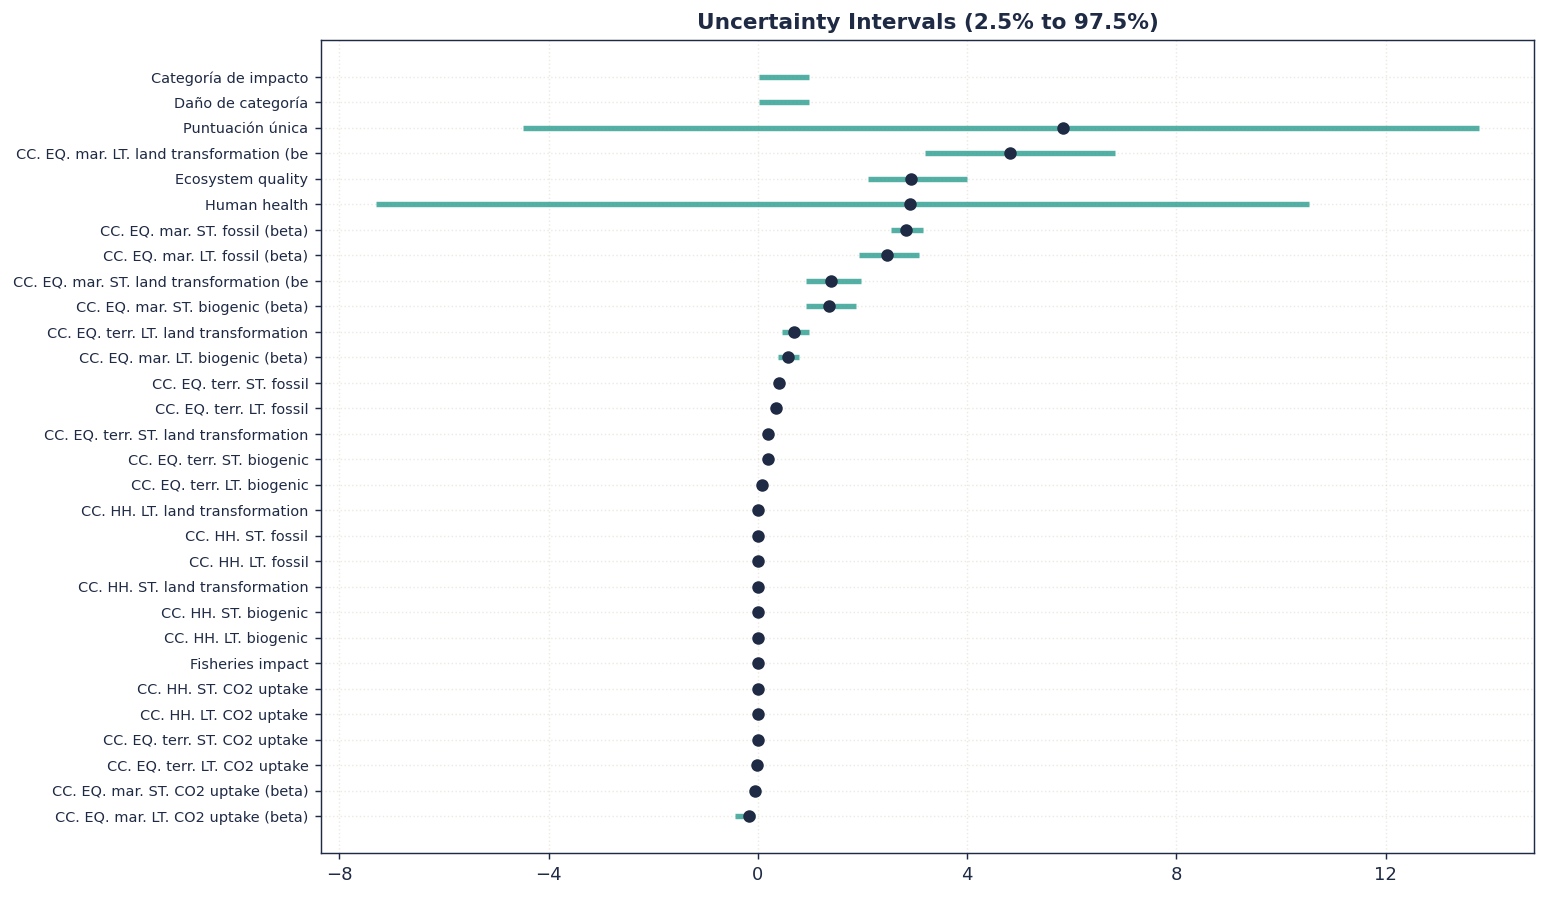

In [8]:

unc_raw = parsed["uncertainty"].copy()

# Normalize likely columns in this sheet
col_map = {}
for c in unc_raw.columns:
    nc = normalize_text(c)
    if "promedio" in nc or "mean" in nc:
        col_map[c] = "mean"
    elif "mediana" in nc or "median" in nc:
        col_map[c] = "median"
    elif "sd" in nc:
        col_map[c] = "sd"
    elif "0_025" in slugify(c) or "025" in nc:
        col_map[c] = "p025"
    elif "0_975" in slugify(c) or "975" in nc:
        col_map[c] = "p975"
    elif "categoria" in nc or "dano" in nc or "impact" in nc:
        col_map[c] = "impact_category"

unc = unc_raw.rename(columns=col_map).copy()
for c in ["mean", "median", "sd", "p025", "p975"]:
    if c in unc.columns:
        unc[c] = pd.to_numeric(unc[c], errors="coerce")

if "impact_category" not in unc.columns:
    unc["impact_category"] = unc.index.map(lambda i: f"impact_{i}")

unc = unc.dropna(subset=[c for c in ["mean", "p025", "p975"] if c in unc.columns], how="all")
unc = unc.head(30).copy()
unc["source_summary_file"] = str(SUMMARY_FILES["crop_national"].relative_to(ROOT))
unc["source_inventory_level"] = "uncertainty"
unc["source_key"] = unc["impact_category"].astype(str).map(normalize_text)
unc["n"] = int(summary_tables["crop_national"]["count"].sum())

if {"p025", "p975"}.issubset(set(unc.columns)) and len(unc):
    fig, ax = plt.subplots(figsize=(12, 7))
    show = unc.sort_values("mean") if "mean" in unc.columns else unc.copy()
    y = np.arange(len(show))
    xmid = show["mean"] if "mean" in show.columns else (show["p025"] + show["p975"]) / 2
    ax.hlines(y, show["p025"], show["p975"], color=PALETTE["accent2"], lw=3, alpha=0.8)
    ax.scatter(xmid, y, color=PALETTE["ink"], s=35, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(show["impact_category"].astype(str), fontsize=8)
    ax.set_title("Uncertainty Intervals (2.5% to 97.5%)")
    ax.xaxis.set_major_locator(MaxNLocator(6))
    fig.tight_layout()
    fig.savefig(OUT_FIGS / "uncertainty_interval_forest.png", bbox_inches="tight", transparent=True)
    fig.savefig(OUT_FIGS / "uncertainty_interval_forest.svg", bbox_inches="tight", transparent=True)

unc.to_csv(OUT_REPORTS / "7_lcia_uncertainty_enriched.csv", index=False)
display(unc.head(20))


In [9]:

# ---------- Reference Index + Coverage ----------
ref_frames = []

if 'espac_imp' in globals() and isinstance(espac_imp, pd.DataFrame) and not espac_imp.empty:
    ref_frames.append(espac_imp.assign(metric=espac_imp["metric"].map(compact_metric_label))[["metric", "domain", "source_summary_file", "source_inventory_level", "source_key", "n"]].assign(sheet_name="ESPAC", figure_id="espac_fingerprint_matrix_by_domain"))
if 'reg_df' in globals() and isinstance(reg_df, pd.DataFrame) and not reg_df.empty:
    ref_frames.append(reg_df.assign(metric=reg_df["metric"].map(compact_metric_label), figure_id=reg_df["figure_family"]).rename(columns={"figure_id":"figure_id"})[["metric", "domain", "source_summary_file", "source_inventory_level", "source_key", "n", "figure_id"]].assign(sheet_name="regional differences"))
if 'cmp_imp' in globals() and isinstance(cmp_imp, pd.DataFrame) and not cmp_imp.empty:
    ref_frames.append(cmp_imp[["metric", "domain", "source_summary_file", "source_inventory_level", "source_key", "n", "figure_family"]].rename(columns={"figure_family":"figure_id"}).assign(sheet_name="comparisons"))
if 'itc' in globals() and isinstance(itc, pd.DataFrame) and not itc.empty:
    ref_frames.append(itc[["crop_candidate", "source_summary_file", "source_inventory_level", "source_key", "n"]].rename(columns={"crop_candidate": "metric"}).assign(sheet_name="individual tropical crops", figure_id="individual_tropical_crops_grouped_lollipop", domain="crops"))
if 'unc' in globals() and isinstance(unc, pd.DataFrame) and not unc.empty:
    ref_frames.append(unc[["impact_category", "source_summary_file", "source_inventory_level", "source_key", "n"]].rename(columns={"impact_category": "metric"}).assign(sheet_name="uncertainty", figure_id="uncertainty_interval_forest", domain="other"))

reference_index = pd.concat(ref_frames, ignore_index=True) if ref_frames else pd.DataFrame(columns=["metric", "domain", "source_summary_file", "source_inventory_level", "source_key", "n", "sheet_name", "figure_id"])
reference_index.to_csv(OUT_REPORTS / "7_lcia_reference_index.csv", index=False)

coverage = reference_index.groupby(["sheet_name", "figure_id", "domain"], as_index=False).agg(
    rows=("metric", "size"),
    n_non_null=("n", lambda s: int(pd.Series(s).notna().sum())),
)
coverage["coverage_pct"] = np.where(coverage["rows"] > 0, coverage["n_non_null"] / coverage["rows"] * 100, 0.0)
coverage.to_csv(OUT_REPORTS / "7_lcia_reference_coverage.csv", index=False)

unmatched = reference_index[reference_index["n"].isna()].copy()
unmatched.to_csv(OUT_REPORTS / "7_lcia_unmatched_references.csv", index=False)

print("Saved outputs:")
print("-", OUT_REPORTS / "7_lcia_reference_index.csv")
print("-", OUT_REPORTS / "7_lcia_reference_coverage.csv")
print("-", OUT_REPORTS / "7_lcia_unmatched_references.csv")
print("Figures in:", OUT_FIGS)
display(coverage)


Saved outputs:
- c:\Users\AAVADI\OneDrive - IRTA\Documents\_Proyectos\ESPAC\outputs\reports\7_lcia_reference_index.csv
- c:\Users\AAVADI\OneDrive - IRTA\Documents\_Proyectos\ESPAC\outputs\reports\7_lcia_reference_coverage.csv
- c:\Users\AAVADI\OneDrive - IRTA\Documents\_Proyectos\ESPAC\outputs\reports\7_lcia_unmatched_references.csv
Figures in: c:\Users\AAVADI\OneDrive - IRTA\Documents\_Proyectos\ESPAC\outputs\reports\figures_lcia_poster


,sheet_name,figure_id,domain,rows,n_non_null,coverage_pct
0,ESPAC,espac_fingerprint_matrix_by_domain,crops,7,7,100.000000
1,ESPAC,espac_fingerprint_matrix_by_domain,livestock,10,10,100.000000
2,comparisons,comparisons_eggs_all_sources,livestock,3,3,100.000000
3,comparisons,comparisons_milk_all_sources,livestock,3,3,100.000000
4,individual tropical crops,individual_tropical_crops_grouped_lollipop,crops,124,115,92.741935
5,regional differences,regional_dumbbell_provinces,crops,27,27,100.000000
6,regional differences,regional_dumbbell_regions,crops,27,27,100.000000
7,uncertainty,uncertainty_interval_forest,other,30,30,100.000000
